In [62]:
import os
import glob
import inspect
import numpy as np
import matplotlib.pyplot as plt

import healpy as hp
from astropy.io import fits

import limTOD
from limTOD import generate_LSTs_deg, generate_TOD_sky
from limTOD import GDSM_sky_model
from limTOD import HPW_mapmaking

print("limTOD imported from:")
print(limTOD.__file__)

print("\nHPW_mapmaking from:")
print(inspect.getfile(HPW_mapmaking))

print("\nHPW_mapmaking.__call__ signature:")
print(inspect.signature(HPW_mapmaking.__call__))

limTOD imported from:
/Users/user/LimTOD/rhino-TODsim/limTOD/__init__.py

HPW_mapmaking from:
/Users/user/LimTOD/rhino-TODsim/limTOD/HPW_filter.py

HPW_mapmaking.__call__ signature:
(self, *, TOD_group, dtime, cutoff_freq_group=None, gain_group=None, known_injection_group=None, Tsky_prior_mean=None, Tsky_prior_inv_cov_diag=None, Tsys_other_prior_mean_group=None, Tsys_other_prior_inv_cov_group=None, noise_variance=None, regularization=1e-12, return_full_cov=False, filter_order=4, preserve_dc=False, use_high_pass=False)


In [83]:
# ============================================================
# USER SETTINGS
# ============================================================

FREQ_MHZ = 70.0

# Keep simulation and mapmaking at same low resolution first
NSIDE = 4

# Beam folder from your copied/symlinked data
#BEAM_DIR = os.path.expanduser("~/LimTOD/rhino-TODsim/data/HornDry")
BEAM_DIR = os.path.expanduser("~/LimTOD/rhino-TODsim/data/DipoleDry")

# North pole
ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H   = 0.0

START_TIME = "2026-04-01 00:00:00"

# 4 hour simulation
N_HOURS = 24
DT = 30.0
N_TIME = int(N_HOURS * 3600 / DT)

time_list = np.arange(N_TIME) * DT
time_hours = time_list / 3600.0

# Zenith pointing
azimuth_deg_list = np.zeros(N_TIME)
elevation_deg_list = np.ones(N_TIME) * 90.0

# Antenna rotation: 360 degrees per hour
selfrot_deg_list = (360.0 * time_hours) % 360.0

# Mapmaker settings
THRESHOLD = 0.05
TRUNC_FRAC = THRESHOLD

REGULARIZATION = 1e-6

# No 1/f noise in this controlled test
USE_HIGH_PASS = False
CUTOFF_FREQ = 1e-8
FILTER_ORDER = 4

# Mild prior comparison
MILD_PRIOR_SIGMA_FACTOR = 0.3

print(f"N_TIME = {N_TIME}")
print(f"Samples per rotation = {3600 / DT:.0f}")
print(f"Total rotations = {N_HOURS}")

N_TIME = 2880
Samples per rotation = 120
Total rotations = 24


In [ ]:
import re

def extract_frequency_from_filename(path):
    """
    Extract a frequency like 70.0 from filenames such as:
    DipoleDry70.0.fits, DipoleDry_70MHz.fits, HornWet55.0.fits, etc.
    """
    name = os.path.basename(path)

    patterns = [
        r"(\d+(?:\.\d+)?)\s*MHz",
        r"(\d+(?:\.\d+)?)\.fits",
        r"(\d+(?:\.\d+)?)"
    ]

    for pat in patterns:
        matches = re.findall(pat, name, flags=re.IGNORECASE)
        if matches:
            nums = [float(m) for m in matches]
            
            return nums[-1]

    return None


def find_closest_beam_file(beam_dir, target_freq_mhz):
    files = sorted(glob.glob(os.path.join(beam_dir, "*.fits")))

    if len(files) == 0:
        raise FileNotFoundError(f"No FITS files found in: {beam_dir}")

    candidates = []
    for f in files:
        freq = extract_frequency_from_filename(f)
        if freq is not None:
            candidates.append((abs(freq - target_freq_mhz), freq, f))

    if len(candidates) == 0:
        raise RuntimeError(
            f"Could not infer frequencies from FITS filenames in {beam_dir}."
        )

    candidates.sort(key=lambda x: x[0])
    diff, freq, path = candidates[0]

    print("Selected beam file:")
    print(path)
    print(f"Beam file frequency inferred from name: {freq:.3f} MHz")
    print(f"Requested frequency: {target_freq_mhz:.3f} MHz")
    print(f"Difference: {diff:.3f} MHz")

    return path, freq


beam_file, beam_file_freq = find_closest_beam_file(BEAM_DIR, FREQ_MHZ)

Selected beam file:
/Users/user/LimTOD/rhino-TODsim/data/DipoleDry/DipoleDry70.0.fits
Beam file frequency inferred from name: 70.000 MHz
Requested frequency: 70.000 MHz
Difference: 0.000 MHz


In [ ]:
def infer_nside_from_size(npix):
    nside = hp.npix2nside(npix)
    if hp.nside2npix(nside) != npix:
        raise ValueError(f"Array length {npix} is not a valid HEALPix NPIX.")
    return nside


def load_healpix_beam_from_fits(path, target_nside=None, field_index=0, assume_ring=True):
    """
    Robustly load a HEALPix beam map from a FITS file.

    Handles:
    - Image HDUs containing a 1D HEALPix map
    - Binary table HDUs with scalar rows
    - Binary table HDUs with vector columns

    Returns:
    - beam map at target_nside if given
    """

    print(f"Loading beam FITS:\n{path}")

    with fits.open(path) as hdul:
        print("\nFITS structure:")
        hdul.info()

        beam = None

        # image HDUs first
        for hdu in hdul:
            data = hdu.data
            if data is None:
                continue

            arr = np.asarray(data)

            if arr.ndim == 1:
                try:
                    infer_nside_from_size(arr.size)
                    beam = arr.astype(float)
                    print("\nLoaded beam from 1D image HDU.")
                    break
                except Exception:
                    pass

            if arr.ndim > 1:
                flat = arr.ravel()
                try:
                    infer_nside_from_size(flat.size)
                    beam = flat.astype(float)
                    print("\nLoaded beam from flattened image HDU.")
                    break
                except Exception:
                    pass

        # binary table HDUs
        if beam is None:
            for hdu in hdul:
                data = hdu.data
                if data is None:
                    continue

                if not hasattr(data, "columns"):
                    continue

                colnames = data.columns.names
                print("\nTrying table columns:", colnames)

                # Prefer requested field index, but search all columns if needed
                ordered_cols = [colnames[field_index]] + [
                    c for c in colnames if c != colnames[field_index]
                ]

                for col in ordered_cols:
                    arr = np.asarray(data[col])

                    # Case 1: one scalar per pixel
                    if arr.ndim == 1:
                        try:
                            infer_nside_from_size(arr.size)
                            beam = arr.astype(float)
                            print(f"Loaded scalar HEALPix column: {col}")
                            break
                        except Exception:
                            pass

                    # Case 2: rows contain vector chunks
                    flat = arr.ravel()
                    try:
                        infer_nside_from_size(flat.size)
                        beam = flat.astype(float)
                        print(f"Loaded vector HEALPix column: {col}")
                        break
                    except Exception:
                        pass

                if beam is not None:
                    break

    if beam is None:
        raise RuntimeError(f"Could not find a valid HEALPix beam map in {path}")

    beam = np.asarray(beam, dtype=float)
    beam = np.nan_to_num(beam, nan=0.0, posinf=0.0, neginf=0.0)

    input_nside = infer_nside_from_size(beam.size)
    print(f"\nInput beam NSIDE = {input_nside}")
    print(f"Input beam min/max = {beam.min():.4e}, {beam.max():.4e}")

    # Use absolute if beam has tiny negative numerical values
    if beam.min() < 0:
        print("Warning: beam has negative values. Taking absolute value for power response.")
        beam = np.abs(beam)

    # Degrade to target NSIDE
    if target_nside is not None and target_nside != input_nside:
        beam = hp.ud_grade(beam, nside_out=target_nside, power=0)
        beam = np.nan_to_num(beam, nan=0.0, posinf=0.0, neginf=0.0)
        print(f"Degraded beam to NSIDE = {target_nside}")

    # Normalize peak to 1.
    # This keeps thresholding meaningful and makes beam convention stable.
    peak = np.max(np.abs(beam))
    if peak <= 0:
        raise ValueError("Beam peak is zero; cannot normalize.")

    beam = beam / peak

    print(f"Final beam NSIDE = {hp.npix2nside(len(beam))}")
    print(f"Final beam min/max = {beam.min():.4e}, {beam.max():.4e}")
    print(f"Final beam mean = {beam.mean():.4e}")

    return beam


beam_map = load_healpix_beam_from_fits(
    beam_file,
    target_nside=NSIDE,
    field_index=0
)

Loading beam FITS:
/Users/user/LimTOD/rhino-TODsim/data/DipoleDry/DipoleDry70.0.fits

FITS structure:
Filename: /Users/user/LimTOD/rhino-TODsim/data/DipoleDry/DipoleDry70.0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   3072R x 1C   [1024D]   

Loaded beam from 1D image HDU.

Input beam NSIDE = 16
Input beam min/max = 9.0250e-03, 4.8659e+00
Degraded beam to NSIDE = 4
Final beam NSIDE = 4
Final beam min/max = 2.2852e-03, 1.0000e+00
Final beam mean = 1.7534e-01


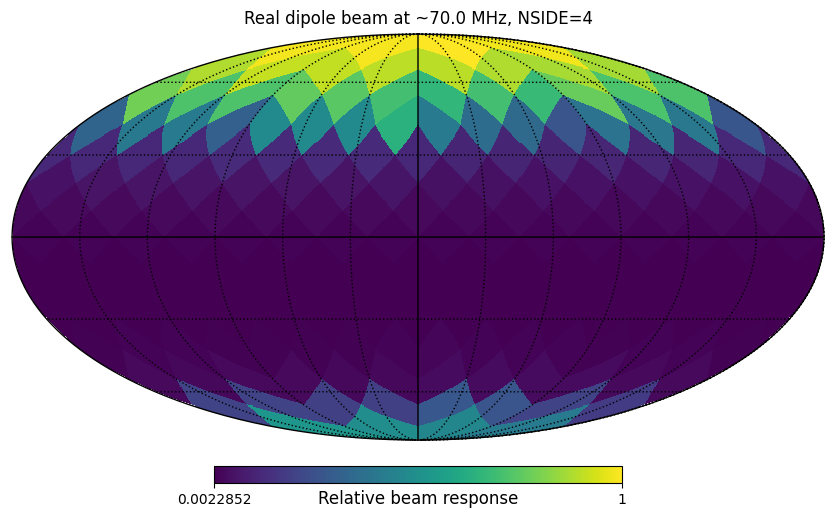

Beam diagnostics:
NSIDE: 4
NPIX: 192
min: 0.002285196243055098
max: 1.0
mean: 0.17533829855101543
nonzero pixels: 192


In [86]:
hp.mollview(
    beam_map,
    title=f"Real dipole beam at ~{beam_file_freq:.1f} MHz, NSIDE={NSIDE}",
    unit="Relative beam response",
    cmap="viridis"
)
hp.graticule()
plt.show()

print("Beam diagnostics:")
print("NSIDE:", hp.npix2nside(len(beam_map)))
print("NPIX:", len(beam_map))
print("min:", np.min(beam_map))
print("max:", np.max(beam_map))
print("mean:", np.mean(beam_map))
print("nonzero pixels:", np.count_nonzero(beam_map))

Sky diagnostics:
NSIDE: 4
NPIX: 192
min: 1234.27685546875 K
max: 14255.650390625 K
mean: 2757.6338634490967 K


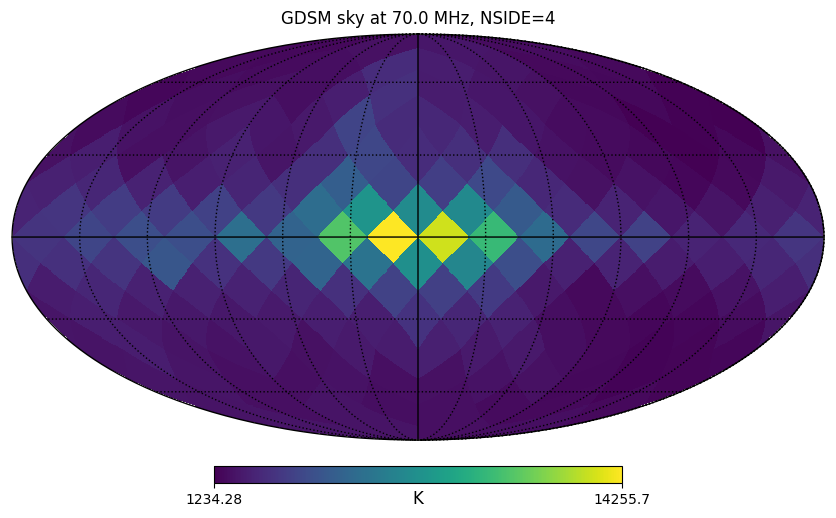

In [ ]:
sky_map = GDSM_sky_model(freq=FREQ_MHZ, nside=NSIDE)
sky_map = np.asarray(sky_map, dtype=float)
sky_map = np.nan_to_num(sky_map, nan=0.0, posinf=0.0, neginf=0.0)

print("Sky diagnostics:")
print("NSIDE:", hp.npix2nside(len(sky_map)))
print("NPIX:", len(sky_map))
print("min:", np.min(sky_map), "K")
print("max:", np.max(sky_map), "K")
print("mean:", np.mean(sky_map), "K")

hp.mollview(
    sky_map,
    title=f"GDSM sky at {FREQ_MHZ:.1f} MHz, NSIDE={NSIDE}",
    unit="K",
    cmap="viridis"
)
hp.graticule()
plt.show()

In [88]:
print("generate_LSTs_deg signature:")
print(inspect.signature(generate_LSTs_deg))

generate_LSTs_deg signature:
(ant_latitude_deg, ant_longitude_deg, ant_height_m, time_list, start_time_utc='2019-04-23 20:41:56.397')


In [89]:
LST_deg_list = generate_LSTs_deg(
    ant_latitude_deg=ANT_LAT,
    ant_longitude_deg=ANT_LON,
    ant_height_m=ANT_H,
    time_list=time_list,
    start_time_utc=START_TIME,
)

LST_deg_list = np.asarray(LST_deg_list)

print("LST diagnostics:")
print("Shape:", LST_deg_list.shape)
print("First five LSTs:", LST_deg_list[:5])
print("Min/max:", np.min(LST_deg_list), np.max(LST_deg_list))

LST diagnostics:
Shape: (2880,)
First five LSTs: [187.06419745 187.18953968 187.3148819  187.44022413 187.56556635]
Min/max: 0.03646690047721769 359.9111246760663


In [90]:
print("generate_TOD_sky signature:")
print(inspect.signature(generate_TOD_sky))

generate_TOD_sky signature:
(beam_map, sky_map, LST_deg_list, lat_deg, azimuth_deg_list, elevation_deg_list, selfrot_deg_list, nside_hires=None, normalize_beam=False, horizontal_mask=None, truncate_frac_thres=1e-10)


In [91]:
TOD = generate_TOD_sky(
    beam_map=beam_map,
    sky_map=sky_map,
    LST_deg_list=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list=azimuth_deg_list,
    elevation_deg_list=elevation_deg_list,
    selfrot_deg_list=selfrot_deg_list,
    normalize_beam=False,
    truncate_frac_thres=TRUNC_FRAC,
)

TOD = np.asarray(TOD, dtype=float)

print("TOD diagnostics:")
print("shape:", TOD.shape)
print("min:", np.min(TOD), "K")
print("max:", np.max(TOD), "K")
print("mean:", np.mean(TOD), "K")
print("std:", np.std(TOD), "K")

100%|██████████| 2880/2880 [00:00<00:00, 12336.11it/s]

TOD diagnostics:
shape: (2880,)
min: 55830.444658401226 K
max: 100938.36094368291 K
mean: 73263.04885534149 K
std: 13459.647304706396 K


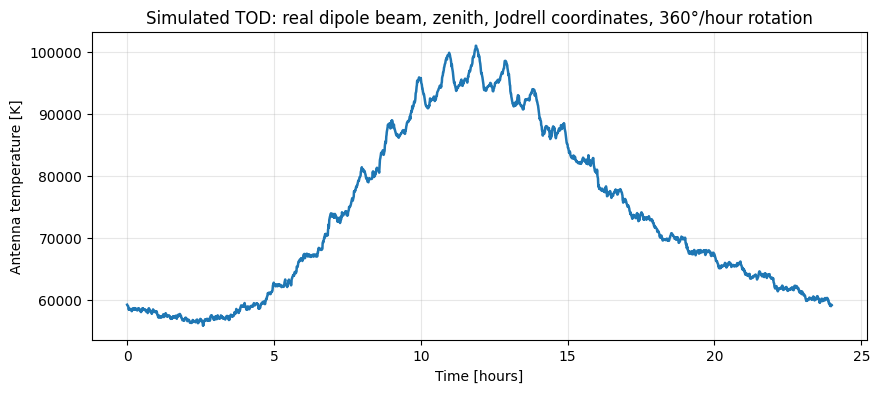

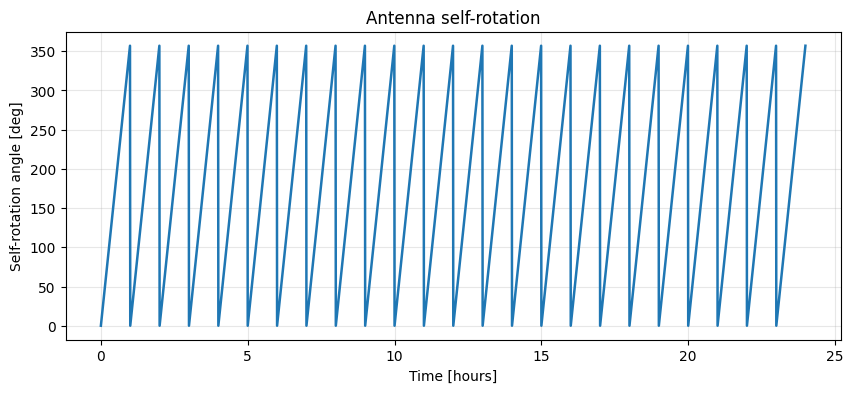

In [97]:
plt.figure(figsize=(10, 4))
plt.plot(time_hours, TOD, lw=1.8)
plt.xlabel("Time [hours]")
plt.ylabel("Antenna temperature [K]")
plt.title("Simulated TOD: real dipole beam, zenith, Jodrell coordinates, 360°/hour rotation")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_hours, selfrot_deg_list, lw=1.8)
plt.xlabel("Time [hours]")
plt.ylabel("Self-rotation angle [deg]")
plt.title("Antenna self-rotation")
plt.grid(alpha=0.3)
plt.show()

In [98]:
import inspect
from limTOD import HPW_mapmaking

print("HPW_mapmaking init signature:")
print(inspect.signature(HPW_mapmaking))

print("\nHPW_mapmaking.__call__ signature:")
print(inspect.signature(HPW_mapmaking.__call__))

HPW_mapmaking init signature:
(*, beam_map, LST_deg_list_group, lat_deg, azimuth_deg_list_group, elevation_deg_list_group, selfrot_deg_list_group=None, threshold=0.01, Tsys_others_operator_group=None, nside_hires=None, nside_target=None, beam_truncate_frac_thres=None)

HPW_mapmaking.__call__ signature:
(self, *, TOD_group, dtime, cutoff_freq_group=None, gain_group=None, known_injection_group=None, Tsky_prior_mean=None, Tsky_prior_inv_cov_diag=None, Tsys_other_prior_mean_group=None, Tsys_other_prior_inv_cov_group=None, noise_variance=None, regularization=1e-12, return_full_cov=False, filter_order=4, preserve_dc=False, use_high_pass=False)


In [99]:
mapper = HPW_mapmaking(
    beam_map=beam_map,
    LST_deg_list_group=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list_group=azimuth_deg_list,
    elevation_deg_list_group=elevation_deg_list,
    selfrot_deg_list_group=selfrot_deg_list,
    threshold=THRESHOLD,
    beam_truncate_frac_thres=TRUNC_FRAC,
    nside_target=NSIDE,
)

print("Mapper created successfully.")


Step 1: Generating the stacked abs(beam) map ... 



100%|██████████| 2880/2880 [00:00<00:00, 11563.95it/s]



Step 2: Selecting pixels above threshold sensitivity ... 

Number of data points: 2880
Number of selected pixels: 192


100%|██████████| 2880/2880 [00:00<00:00, 13693.99it/s]

Mapper created successfully.


In [100]:
pix = np.asarray(mapper.pixel_indices, dtype=int)

print("Using mapper pixel attribute: pixel_indices")
print("Number of selected pixels:", len(pix))
print("Number of TOD samples:", len(TOD))
print("First few pixel indices:", pix[:10])
print("Pixel index min/max:", pix.min(), pix.max())

Using mapper pixel attribute: pixel_indices
Number of selected pixels: 192
Number of TOD samples: 2880
First few pixel indices: [0 1 2 3 4 5 6 7 8 9]
Pixel index min/max: 0 191


In [101]:
truth_patch = sky_map[pix]

print("Truth patch shape:", truth_patch.shape)
print("Recovered patch shape will be compared after mapmaking.")

Truth patch shape: (192,)
Recovered patch shape will be compared after mapmaking.


In [102]:
sky_est_patch, sky_unc_patch = mapper(
    TOD_group=TOD,
    dtime=DT,
    cutoff_freq_group=None,
    gain_group=1.0,
    Tsky_prior_mean=None,
    Tsky_prior_inv_cov_diag=None,
    noise_variance=None,
    regularization=REGULARIZATION,
    filter_order=FILTER_ORDER,
    preserve_dc=False,
    use_high_pass=False,
)

sky_est_patch = np.asarray(sky_est_patch, dtype=float)
sky_unc_patch = np.asarray(sky_unc_patch, dtype=float)

print("Recovered patch shape:", sky_est_patch.shape)
print("Uncertainty patch shape:", sky_unc_patch.shape)
print("Truth patch shape:", truth_patch.shape)

Recovered patch shape: (192,)
Uncertainty patch shape: (192,)
Truth patch shape: (192,)


In [103]:
residual_patch = sky_est_patch - truth_patch

rmse = np.sqrt(np.mean(residual_patch**2))
bias = np.mean(residual_patch)

if np.std(sky_est_patch) > 0 and np.std(truth_patch) > 0:
    corr = np.corrcoef(sky_est_patch, truth_patch)[0, 1]
else:
    corr = np.nan

print("No-prior mapmaking diagnostics")
print("--------------------------------")
print(f"Selected pixels : {len(pix)}")
print(f"TOD samples     : {len(TOD)}")
print(f"RMSE [K]        : {rmse:.4f}")
print(f"Bias [K]        : {bias:.4f}")
print(f"Correlation     : {corr:.4f}")

No-prior mapmaking diagnostics
--------------------------------
Selected pixels : 192
TOD samples     : 2880
RMSE [K]        : 0.0000
Bias [K]        : 0.0000
Correlation     : 1.0000


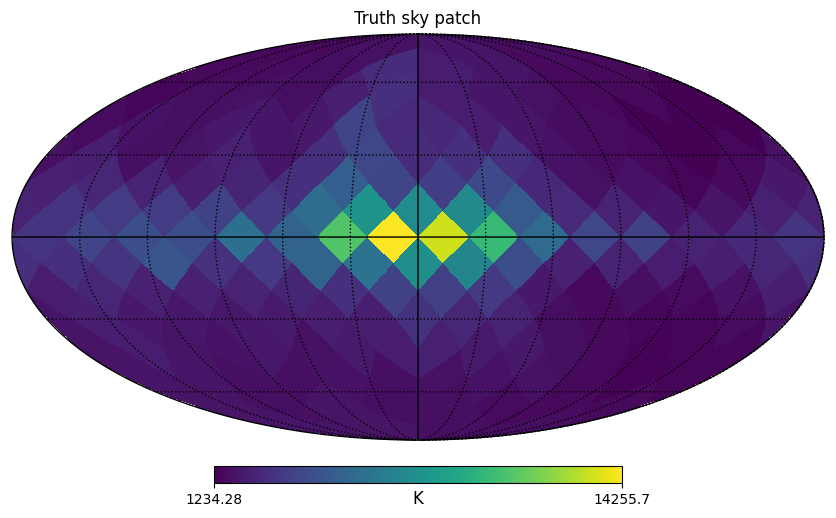

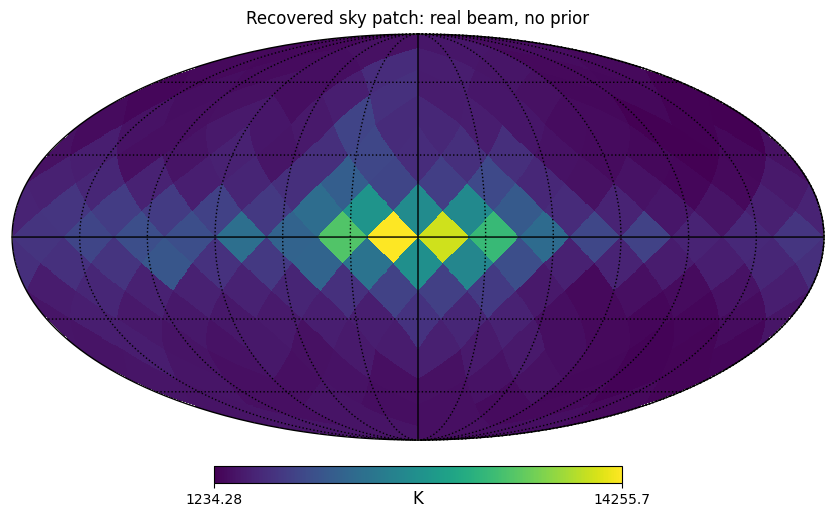

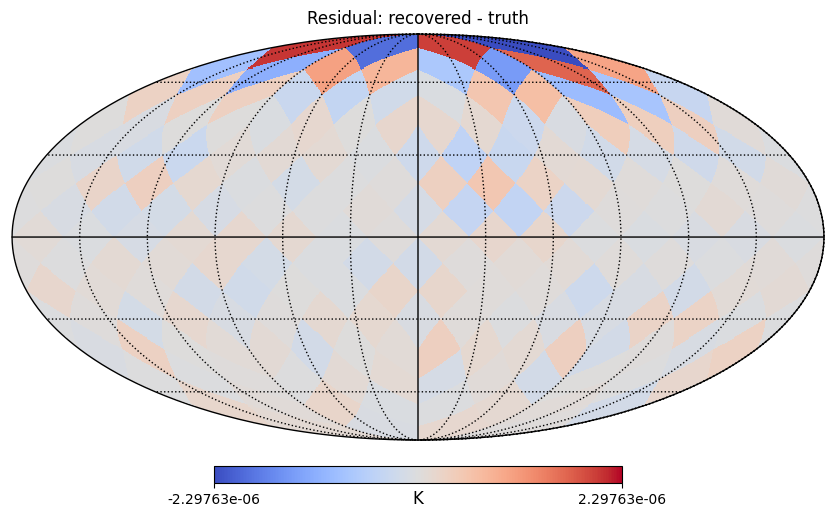

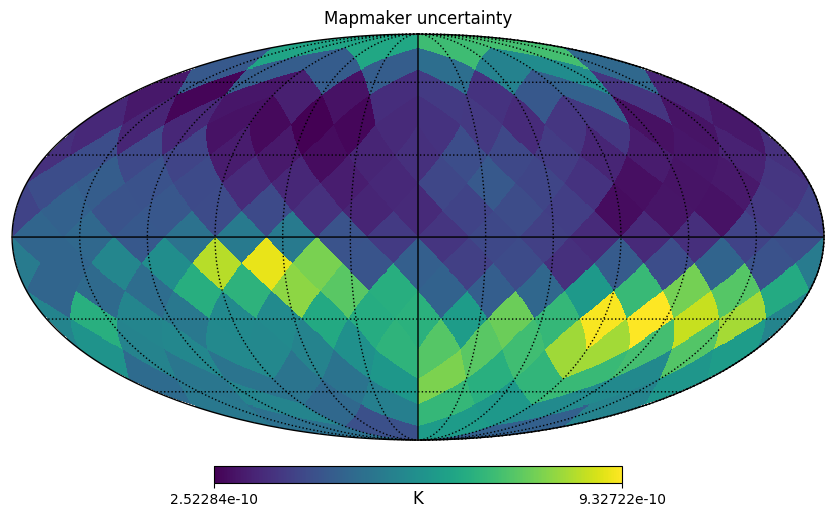

In [104]:
def patch_to_full_map(pix, values, nside, unseen=hp.UNSEEN):
    full_map = np.full(hp.nside2npix(nside), unseen, dtype=float)
    full_map[pix] = values
    return full_map

truth_full = patch_to_full_map(pix, truth_patch, NSIDE)
recovered_full = patch_to_full_map(pix, sky_est_patch, NSIDE)
residual_full = patch_to_full_map(pix, residual_patch, NSIDE)
unc_full = patch_to_full_map(pix, sky_unc_patch, NSIDE)

vmin = np.nanmin(truth_patch)
vmax = np.nanmax(truth_patch)

hp.mollview(
    truth_full,
    title="Truth sky patch",
    unit="K",
    min=vmin,
    max=vmax,
    cmap="viridis",
)
hp.graticule()
plt.show()

hp.mollview(
    recovered_full,
    title="Recovered sky patch: real beam, no prior",
    unit="K",
    min=vmin,
    max=vmax,
    cmap="viridis",
)
hp.graticule()
plt.show()

res_lim = np.nanmax(np.abs(residual_patch))

hp.mollview(
    residual_full,
    title="Residual: recovered - truth",
    unit="K",
    min=-res_lim,
    max=res_lim,
    cmap="coolwarm",
)
hp.graticule()
plt.show()

hp.mollview(
    unc_full,
    title="Mapmaker uncertainty",
    unit="K",
    cmap="viridis",
)
hp.graticule()
plt.show()

In [82]:
print("truth_patch shape:", truth_patch.shape)
print("sky_est_patch shape:", sky_est_patch.shape)

diff = sky_est_patch - truth_patch

print("Max abs difference:", np.max(np.abs(diff)))
print("Mean abs difference:", np.mean(np.abs(diff)))
print("RMSE:", np.sqrt(np.mean(diff**2)))
print("Are they exactly equal?", np.array_equal(sky_est_patch, truth_patch))
print("Are they close?", np.allclose(sky_est_patch, truth_patch))

truth_patch shape: (88,)
sky_est_patch shape: (88,)
Max abs difference: 4.614912541001104e-08
Mean abs difference: 9.237859124120652e-09
RMSE: 1.3598993706073178e-08
Are they exactly equal? False
Are they close? True


## Full Gaussian TOD + mapmaking code

In [120]:
# ============================================================
# Gaussian beam TOD + mapmaking config
# ============================================================

FREQ_MHZ = 70.0

# High-resolution grid used for TOD generation
BEAM_NSIDE = 32
SKY_NSIDE = 32

# Low-resolution mapmaker output
MAP_NSIDE = 4     # change to 8 later

GAUSS_FWHM_DEG = 40.0

# Site
ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H   = 0.0

START_TIME = "2026-04-01 00:00:00"

# Observation
N_HOURS = 24
DT = 30.0
N_TIME = int(N_HOURS * 3600 / DT)

time_list = np.arange(N_TIME) * DT
time_hours = time_list / 3600.0

# Zenith pointing
azimuth_deg_list = np.zeros(N_TIME)
elevation_deg_list = np.ones(N_TIME) * 90.0

# Rotation case
selfrot_deg_list = (360.0 * time_hours) % 360.0

# Mapmaker settings
THRESHOLD = 0.05
TRUNC_FRAC = THRESHOLD

REGULARIZATION = 1e-6

USE_HIGH_PASS = False
CUTOFF_FREQ = None
FILTER_ORDER = 4

print("Gaussian TOD simulation config")
print("--------------------------------")
print(f"FREQ_MHZ     = {FREQ_MHZ}")
print(f"BEAM_NSIDE   = {BEAM_NSIDE}")
print(f"SKY_NSIDE    = {SKY_NSIDE}")
print(f"MAP_NSIDE    = {MAP_NSIDE}")
print(f"FWHM         = {GAUSS_FWHM_DEG} deg")
print(f"N_TIME       = {N_TIME}")
print(f"N_HOURS      = {N_HOURS}")
print(f"DT           = {DT} s")
print(f"THRESHOLD    = {THRESHOLD}")
print(f"TRUNC_FRAC   = {TRUNC_FRAC}")

Gaussian TOD simulation config
--------------------------------
FREQ_MHZ     = 70.0
BEAM_NSIDE   = 32
SKY_NSIDE    = 32
MAP_NSIDE    = 4
FWHM         = 40.0 deg
N_TIME       = 2880
N_HOURS      = 24
DT           = 30.0 s
THRESHOLD    = 0.05
TRUNC_FRAC   = 0.05


Gaussian beam diagnostics
-------------------------
NSIDE: 32
NPIX : 12288
min  : 1.0295745688916673e-24
max  : 1.0
mean : 0.04281341942858549
std  : 0.1412625069956807


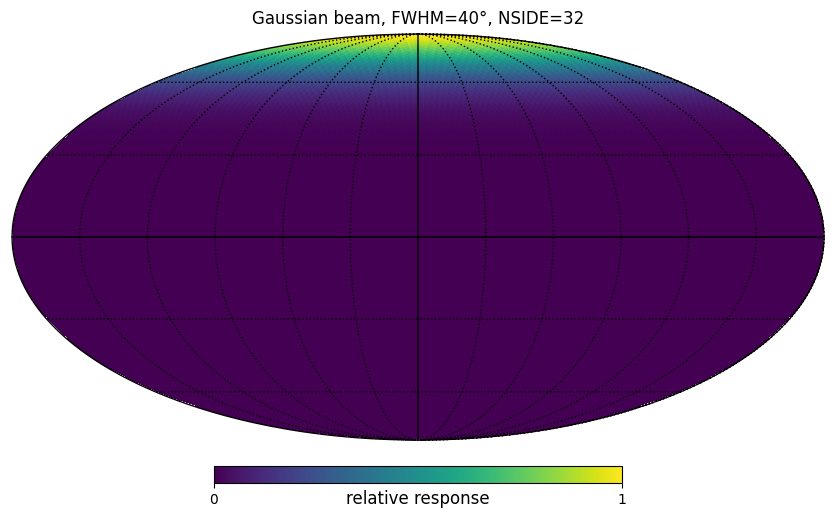

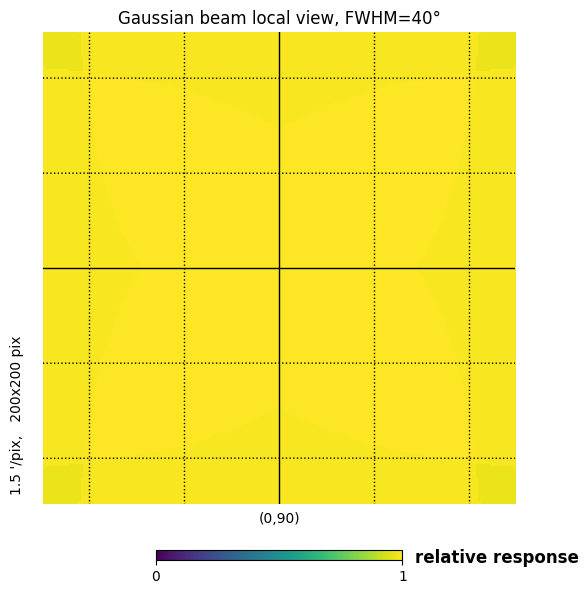

In [126]:
# ============================================================
# Make Gaussian beam at BEAM_NSIDE
# ============================================================

def make_circular_gaussian_beam(nside, fwhm_deg):
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix))

    fwhm_rad = np.deg2rad(fwhm_deg)
    sigma_rad = fwhm_rad / np.sqrt(8.0 * np.log(2.0))

    beam = np.exp(-0.5 * (theta / sigma_rad)**2)

    # Peak-normalise
    beam /= np.max(beam)

    return beam

gaussian_beam_map = make_circular_gaussian_beam(
    nside=BEAM_NSIDE,
    fwhm_deg=GAUSS_FWHM_DEG,
)

print("Gaussian beam diagnostics")
print("-------------------------")
print("NSIDE:", hp.npix2nside(len(gaussian_beam_map)))
print("NPIX :", len(gaussian_beam_map))
print("min  :", np.min(gaussian_beam_map))
print("max  :", np.max(gaussian_beam_map))
print("mean :", np.mean(gaussian_beam_map))
print("std  :", np.std(gaussian_beam_map))

hp.mollview(
    gaussian_beam_map,
    title=f"Gaussian beam, FWHM={GAUSS_FWHM_DEG:.0f}°, NSIDE={BEAM_NSIDE}",
    unit="relative response",
    min=0,
    max=1,
    cmap="viridis",
)
hp.graticule()
plt.show()

hp.gnomview(
    gaussian_beam_map,
    rot=[0, 90],
    title=f"Gaussian beam local view, FWHM={GAUSS_FWHM_DEG:.0f}°",
    unit="relative response",
    min=0,
    max=1,
    cmap="viridis",
)
hp.graticule()
plt.show()

High-resolution sky diagnostics
--------------------------------
NSIDE: 32
NPIX : 12288
min  : -2736.16162109375 K
max  : 73141.6484375 K
mean : 2757.6338613828025 K


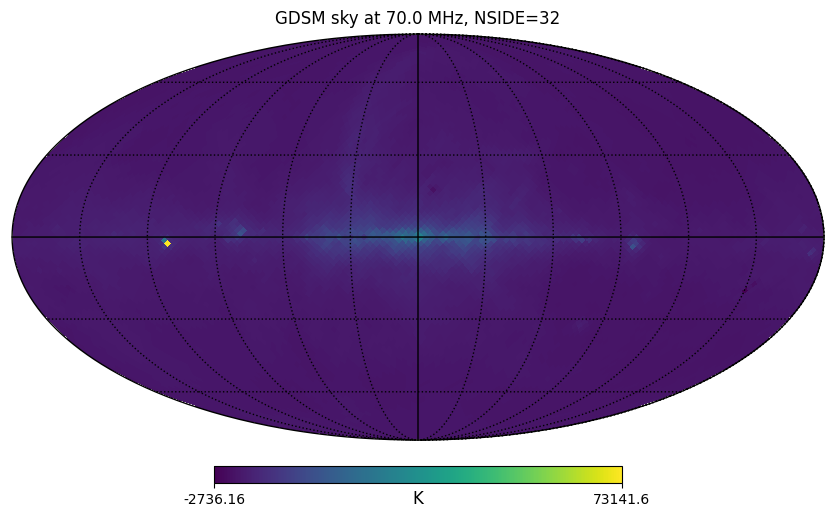

In [127]:
# ============================================================
# Generate GDSM sky at SKY_NSIDE
# ============================================================

sky_map_hires = GDSM_sky_model(freq=FREQ_MHZ, nside=SKY_NSIDE)

sky_map_hires = np.asarray(sky_map_hires, dtype=float)
sky_map_hires = np.nan_to_num(
    sky_map_hires,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
)

print("High-resolution sky diagnostics")
print("--------------------------------")
print("NSIDE:", hp.npix2nside(len(sky_map_hires)))
print("NPIX :", len(sky_map_hires))
print("min  :", np.min(sky_map_hires), "K")
print("max  :", np.max(sky_map_hires), "K")
print("mean :", np.mean(sky_map_hires), "K")

hp.mollview(
    sky_map_hires,
    title=f"GDSM sky at {FREQ_MHZ:.1f} MHz, NSIDE={SKY_NSIDE}",
    unit="K",
    cmap="viridis",
)
hp.graticule()
plt.show()

In [128]:
# ============================================================
# Generate LSTs
# ============================================================

LST_deg_list = generate_LSTs_deg(
    ant_latitude_deg=ANT_LAT,
    ant_longitude_deg=ANT_LON,
    ant_height_m=ANT_H,
    time_list=time_list,
    start_time_utc=START_TIME,
)

LST_deg_list = np.asarray(LST_deg_list, dtype=float)

print("LST diagnostics")
print("---------------")
print("shape:", LST_deg_list.shape)
print("first five:", LST_deg_list[:5])
print("min/max:", np.min(LST_deg_list), np.max(LST_deg_list))

LST diagnostics
---------------
shape: (2880,)
first five: [187.06419745 187.18953968 187.3148819  187.44022413 187.56556635]
min/max: 0.03646690047721769 359.9111246760663


  0%|          | 0/2880 [00:00<?, ?it/s]

100%|██████████| 2880/2880 [00:02<00:00, 1108.48it/s]


Gaussian TOD diagnostics
------------------------
shape: (2880,)
min  : 733193.9317544035 K
max  : 1406182.944954143 K
mean : 999204.8181133302 K
std  : 214693.24712884813 K


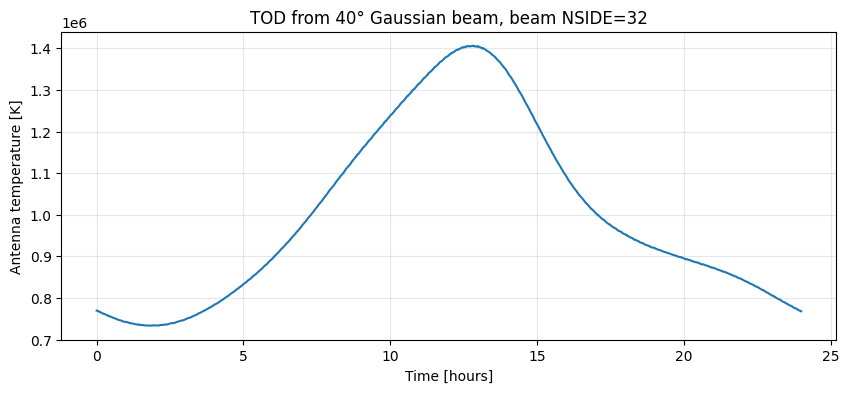

In [129]:
normalize_beam=False
truncate_frac_thres=TRUNC_FRAC

# ============================================================
# Generate TOD using Gaussian beam at NSIDE=32
# ============================================================

TOD_gauss = generate_TOD_sky(
    beam_map=gaussian_beam_map,
    sky_map=sky_map_hires,
    LST_deg_list=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list=azimuth_deg_list,
    elevation_deg_list=elevation_deg_list,
    selfrot_deg_list=selfrot_deg_list,
    nside_hires=BEAM_NSIDE,
    normalize_beam=False,
    truncate_frac_thres=TRUNC_FRAC,
)

TOD_gauss = np.asarray(TOD_gauss, dtype=float)

print("Gaussian TOD diagnostics")
print("------------------------")
print("shape:", TOD_gauss.shape)
print("min  :", np.min(TOD_gauss), "K")
print("max  :", np.max(TOD_gauss), "K")
print("mean :", np.mean(TOD_gauss), "K")
print("std  :", np.std(TOD_gauss), "K")

plt.figure(figsize=(10, 4))
plt.plot(time_hours, TOD_gauss, lw=1.5)
plt.xlabel("Time [hours]")
plt.ylabel("Antenna temperature [K]")
plt.title(
    f"TOD from {GAUSS_FWHM_DEG:.0f}° Gaussian beam, "
    f"beam NSIDE={BEAM_NSIDE}"
)
plt.grid(alpha=0.3)
plt.show()

100%|██████████| 2880/2880 [00:02<00:00, 977.56it/s] 

Rotation sanity check for circular Gaussian beam
-----------------------------------------------
max abs difference: 550.8577869962901 K
mean abs difference: 52.11547324581548 K
relative norm difference: 9.33127377891845e-05


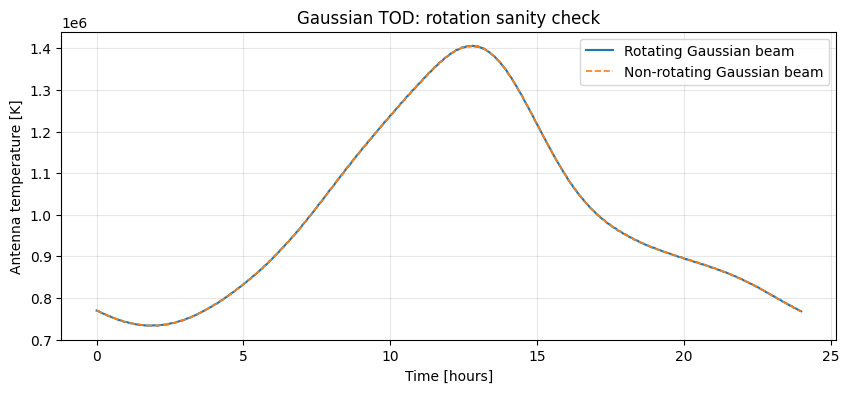

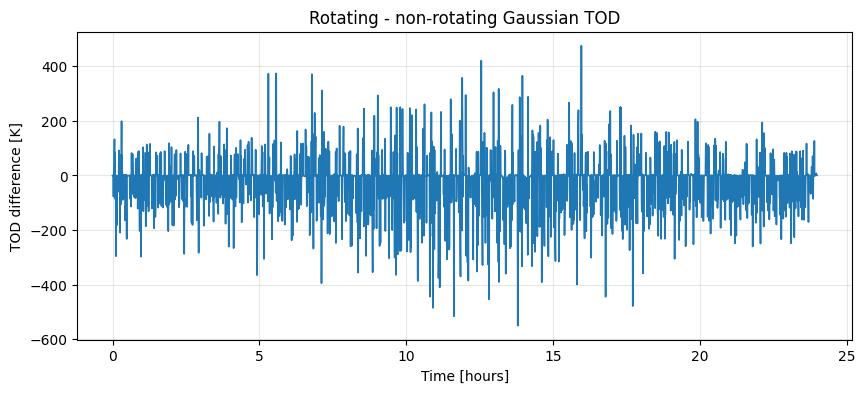

In [130]:
selfrot_zero = np.zeros_like(selfrot_deg_list)

TOD_gauss_no_rot = generate_TOD_sky(
    beam_map=gaussian_beam_map,
    sky_map=sky_map_hires,
    LST_deg_list=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list=azimuth_deg_list,
    elevation_deg_list=elevation_deg_list,
    selfrot_deg_list=selfrot_zero,
    nside_hires=BEAM_NSIDE,
    normalize_beam=False,
    truncate_frac_thres=TRUNC_FRAC,
)

TOD_gauss_no_rot = np.asarray(TOD_gauss_no_rot, dtype=float)

diff_rot = TOD_gauss - TOD_gauss_no_rot

print("Rotation sanity check for circular Gaussian beam")
print("-----------------------------------------------")
print("max abs difference:", np.max(np.abs(diff_rot)), "K")
print("mean abs difference:", np.mean(np.abs(diff_rot)), "K")
print("relative norm difference:", np.linalg.norm(diff_rot) / np.linalg.norm(TOD_gauss))

plt.figure(figsize=(10, 4))
plt.plot(time_hours, TOD_gauss, label="Rotating Gaussian beam", lw=1.5)
plt.plot(time_hours, TOD_gauss_no_rot, "--", label="Non-rotating Gaussian beam", lw=1.2)
plt.xlabel("Time [hours]")
plt.ylabel("Antenna temperature [K]")
plt.title("Gaussian TOD: rotation sanity check")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_hours, diff_rot, lw=1.2)
plt.xlabel("Time [hours]")
plt.ylabel("TOD difference [K]")
plt.title("Rotating - non-rotating Gaussian TOD")
plt.grid(alpha=0.3)
plt.show()

In [131]:
nside_hires=BEAM_NSIDE
nside_target=MAP_NSIDE

# ============================================================
# Mapmaking from Gaussian TOD
# ============================================================

mapper_gauss = HPW_mapmaking(
    beam_map=gaussian_beam_map,
    LST_deg_list_group=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list_group=azimuth_deg_list,
    elevation_deg_list_group=elevation_deg_list,
    selfrot_deg_list_group=selfrot_deg_list,
    threshold=THRESHOLD,
    beam_truncate_frac_thres=TRUNC_FRAC,
    nside_hires=BEAM_NSIDE,
    nside_target=MAP_NSIDE,
)

print("Gaussian mapmaker created.")
print("num_tods    :", mapper_gauss.num_tods)
print("num_pixels  :", mapper_gauss.num_pixels)
print("nsky_params :", mapper_gauss.nsky_params)
print("nside_hires :", mapper_gauss.nside_hires)
print("nside_target:", mapper_gauss.nside_target)


Step 1: Generating the stacked abs(beam) map ... 



100%|██████████| 2880/2880 [00:03<00:00, 793.61it/s] 



Step 2: Selecting pixels above threshold sensitivity ... 

Number of data points: 2880
Number of selected pixels: 72


100%|██████████| 2880/2880 [00:02<00:00, 1276.34it/s]

Gaussian mapmaker created.
num_tods    : 1
num_pixels  : 72
nsky_params : 72
nside_hires : 32
nside_target: 4


In [132]:
# ============================================================
# Target-resolution truth map
# ============================================================

sky_map_target = hp.ud_grade(
    sky_map_hires,
    nside_out=MAP_NSIDE,
    power=0,
)

sky_map_target = np.asarray(sky_map_target, dtype=float)
sky_map_target = np.nan_to_num(
    sky_map_target,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
)

pix_gauss = np.asarray(mapper_gauss.pixel_indices, dtype=int)
truth_patch_gauss = sky_map_target[pix_gauss]

print("Target truth diagnostics")
print("------------------------")
print("sky_map_target NSIDE:", hp.npix2nside(len(sky_map_target)))
print("selected pixels     :", len(pix_gauss))
print("TOD samples         :", len(TOD_gauss))
print("truth patch shape   :", truth_patch_gauss.shape)

Target truth diagnostics
------------------------
sky_map_target NSIDE: 4
selected pixels     : 72
TOD samples         : 2880
truth patch shape   : (72,)


In [133]:
# ============================================================
# Run no-prior Gaussian mapmaking
# ============================================================

sky_est_gauss_patch, sky_unc_gauss_patch = mapper_gauss(
    TOD_group=TOD_gauss,
    dtime=DT,
    cutoff_freq_group=None,
    gain_group=1.0,
    Tsky_prior_mean=None,
    Tsky_prior_inv_cov_diag=None,
    noise_variance=None,
    regularization=REGULARIZATION,
    filter_order=FILTER_ORDER,
    preserve_dc=False,
    use_high_pass=False,
)

sky_est_gauss_patch = np.asarray(sky_est_gauss_patch, dtype=float)
sky_unc_gauss_patch = np.asarray(sky_unc_gauss_patch, dtype=float)

print("Gaussian reconstruction diagnostics")
print("-----------------------------------")
print("recovered patch shape:", sky_est_gauss_patch.shape)
print("uncertainty shape    :", sky_unc_gauss_patch.shape)
print("truth patch shape    :", truth_patch_gauss.shape)
print("recovered min/max    :", np.min(sky_est_gauss_patch), np.max(sky_est_gauss_patch))

Gaussian reconstruction diagnostics
-----------------------------------
recovered patch shape: (72,)
uncertainty shape    : (72,)
truth patch shape    : (72,)
recovered min/max    : 6006.896775752696 272419.48493014136


In [134]:
# ============================================================
# Compare reconstruction to target-resolution truth
# ============================================================

residual_gauss_patch = sky_est_gauss_patch - truth_patch_gauss

rmse_gauss = np.sqrt(np.mean(residual_gauss_patch**2))
bias_gauss = np.mean(residual_gauss_patch)

if np.std(sky_est_gauss_patch) > 0 and np.std(truth_patch_gauss) > 0:
    corr_gauss = np.corrcoef(sky_est_gauss_patch, truth_patch_gauss)[0, 1]
else:
    corr_gauss = np.nan

print("Gaussian TOD mapmaking metrics")
print("------------------------------")
print(f"MAP_NSIDE       : {MAP_NSIDE}")
print(f"BEAM_NSIDE      : {BEAM_NSIDE}")
print(f"Selected pixels : {len(pix_gauss)}")
print(f"TOD samples     : {len(TOD_gauss)}")
print(f"RMSE [K]        : {rmse_gauss:.4f}")
print(f"Bias [K]        : {bias_gauss:.4f}")
print(f"Correlation     : {corr_gauss:.4f}")

Gaussian TOD mapmaking metrics
------------------------------
MAP_NSIDE       : 4
BEAM_NSIDE      : 32
Selected pixels : 72
TOD samples     : 2880
RMSE [K]        : 109944.0772
Bias [K]        : 89412.0123
Correlation     : -0.0613


Gaussian forward consistency check
----------------------------------
relative error = 9.842895e-01


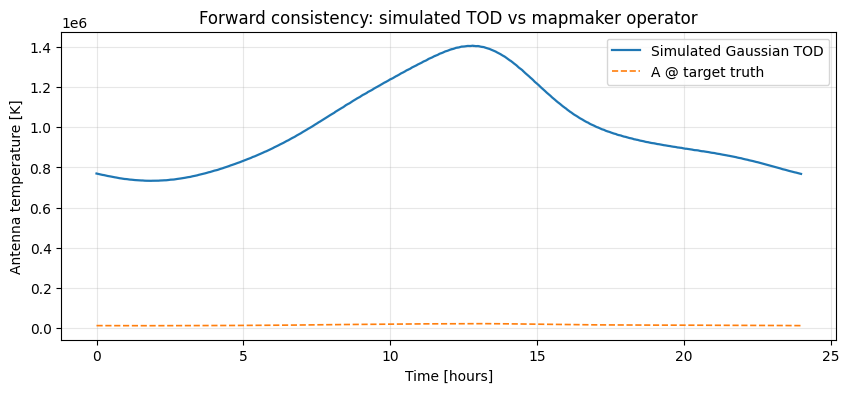

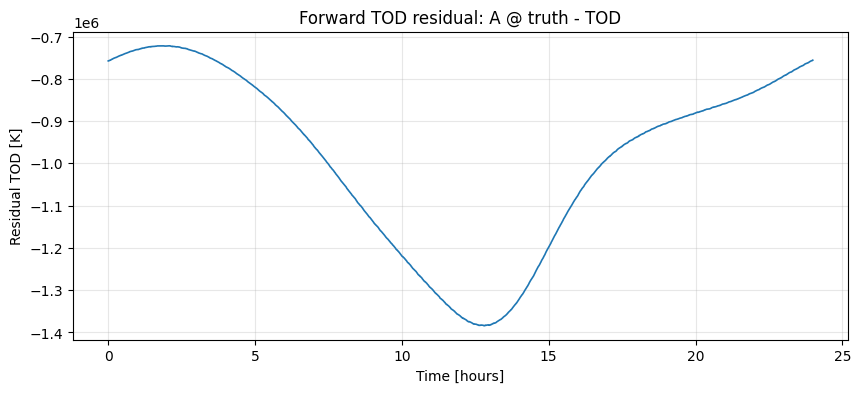

In [135]:
# ============================================================
# Forward consistency check
# ============================================================

A_gauss = mapper_gauss.Tsys_operators

forward_TOD_gauss = A_gauss @ truth_patch_gauss

forward_rel_err_gauss = (
    np.linalg.norm(forward_TOD_gauss - TOD_gauss)
    / np.linalg.norm(TOD_gauss)
)

print("Gaussian forward consistency check")
print("----------------------------------")
print(f"relative error = {forward_rel_err_gauss:.6e}")

plt.figure(figsize=(10, 4))
plt.plot(time_hours, TOD_gauss, label="Simulated Gaussian TOD", lw=1.6)
plt.plot(time_hours, forward_TOD_gauss, "--", label="A @ target truth", lw=1.2)
plt.xlabel("Time [hours]")
plt.ylabel("Antenna temperature [K]")
plt.title("Forward consistency: simulated TOD vs mapmaker operator")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_hours, forward_TOD_gauss - TOD_gauss, lw=1.2)
plt.xlabel("Time [hours]")
plt.ylabel("Residual TOD [K]")
plt.title("Forward TOD residual: A @ truth - TOD")
plt.grid(alpha=0.3)
plt.show()

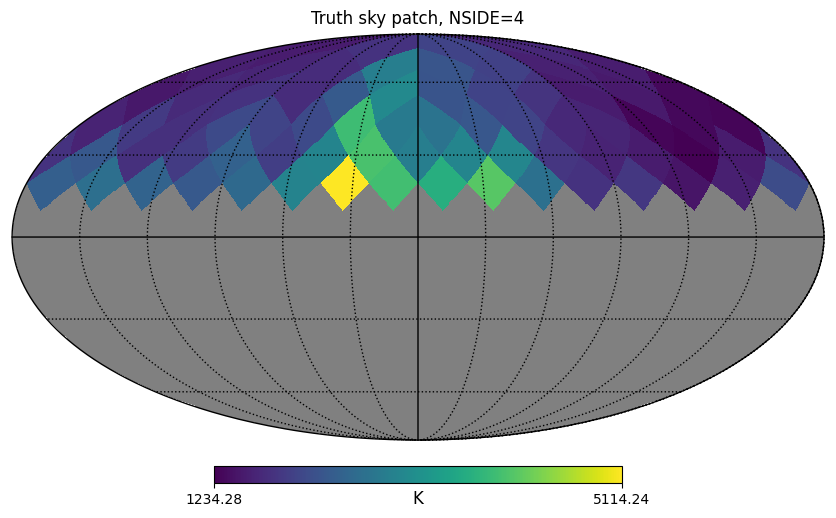

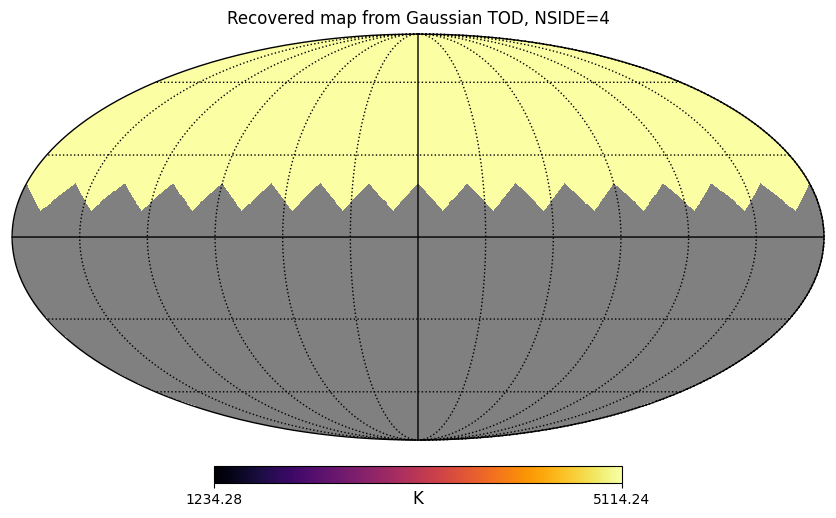

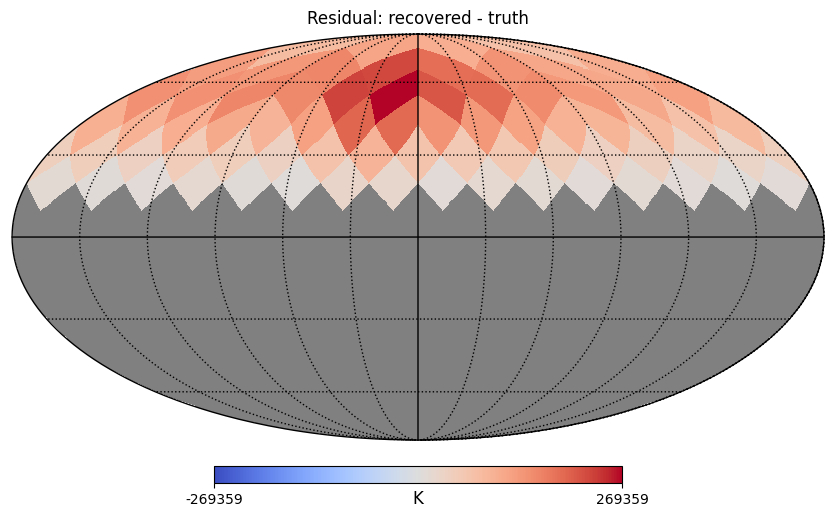

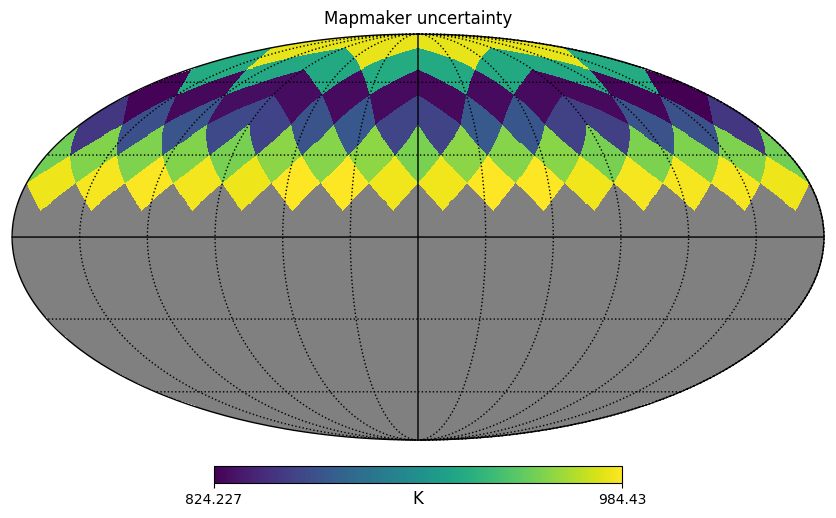

In [137]:
# ============================================================
# Plot truth, recovered, residual
# ============================================================

def patch_to_full_map(pix, values, nside, unseen=hp.UNSEEN):
    full_map = np.full(hp.nside2npix(nside), unseen, dtype=float)
    full_map[pix] = values
    return full_map

truth_gauss_full = patch_to_full_map(
    pix_gauss,
    truth_patch_gauss,
    MAP_NSIDE,
)

recovered_gauss_full = patch_to_full_map(
    pix_gauss,
    sky_est_gauss_patch,
    MAP_NSIDE,
)

residual_gauss_full = patch_to_full_map(
    pix_gauss,
    residual_gauss_patch,
    MAP_NSIDE,
)

unc_gauss_full = patch_to_full_map(
    pix_gauss,
    sky_unc_gauss_patch,
    MAP_NSIDE,
)

vmin = np.nanmin(truth_patch_gauss)
vmax = np.nanmax(truth_patch_gauss)

hp.mollview(
    truth_gauss_full,
    title=f"Truth sky patch, NSIDE={MAP_NSIDE}",
    unit="K",
    min=vmin,
    max=vmax,
    cmap="viridis",
)
hp.graticule()
plt.show()

hp.mollview(
    recovered_gauss_full,
    title=f"Recovered map from Gaussian TOD, NSIDE={MAP_NSIDE}",
    unit="K",
    min=vmin,
    max=vmax,
    cmap="inferno",
)
hp.graticule()
plt.show()

res_lim = np.nanmax(np.abs(residual_gauss_patch))

hp.mollview(
    residual_gauss_full,
    title="Residual: recovered - truth",
    unit="K",
    min=-res_lim,
    max=res_lim,
    cmap="coolwarm",
)
hp.graticule()
plt.show()

hp.mollview(
    unc_gauss_full,
    title="Mapmaker uncertainty",
    unit="K",
    cmap="viridis",
)
hp.graticule()
plt.show()

In [25]:
# ============================================================
# CONSISTENT TOD + MAPMAKER CONFIGURATION
# ============================================================

import os
import glob
import re
import inspect
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

from limTOD import generate_LSTs_deg, generate_TOD_sky
from limTOD import GDSM_sky_model
from limTOD import HPW_mapmaking

# ------------------------------------------------------------
# Frequency
# ------------------------------------------------------------
FREQ_MHZ = 70.0

# ------------------------------------------------------------
# The key consistency choice:
# For this first clean test, simulation NSIDE and mapmaking NSIDE
# must be the same.
# ------------------------------------------------------------
SIM_NSIDE = 32
MAP_NSIDE = 4

# ------------------------------------------------------------
# Beam choice
# ------------------------------------------------------------
USE_GAUSSIAN_BEAM = True
GAUSS_FWHM_DEG = 40.0

# If using real beam later, set USE_GAUSSIAN_BEAM = False
BEAM_DIR = os.path.expanduser("~/LimTOD/rhino-TODsim/data/DipoleDry")

# ------------------------------------------------------------
# Site
# This is NOT the north pole. This is Jodrell-like latitude.
# For true north pole use ANT_LAT = 90.0, ANT_LON = 0.0
# ------------------------------------------------------------
ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H = 0.0

START_TIME = "2026-04-01 00:00:00"

# ------------------------------------------------------------
# Observation setup
# ------------------------------------------------------------
N_HOURS = 24
DT = 30.0

N_TIME = int(N_HOURS * 3600.0 / DT)

time_list = np.arange(N_TIME) * DT
time_hours = time_list / 3600.0

# Zenith pointing
azimuth_deg_list = np.zeros(N_TIME)
elevation_deg_list = np.ones(N_TIME) * 90.0

# Rotation case: 360 degrees per hour
selfrot_deg_list = (360.0 * time_hours) % 360.0

# ------------------------------------------------------------
# Mapmaker settings
# Use the same truncation threshold in TOD and mapmaker.
# ------------------------------------------------------------
THRESHOLD = 0.05
TRUNC_FRAC = THRESHOLD

REGULARIZATION = 1e-6

USE_HIGH_PASS = False
CUTOFF_FREQ = None
FILTER_ORDER = 4

print("Consistent TOD + mapmaker configuration")
print("---------------------------------------")
print(f"FREQ_MHZ     = {FREQ_MHZ}")
print(f"SIM_NSIDE    = {SIM_NSIDE}")
print(f"MAP_NSIDE    = {MAP_NSIDE}")
print(f"N_HOURS      = {N_HOURS}")
print(f"DT           = {DT} s")
print(f"N_TIME       = {N_TIME}")
print(f"ANT_LAT      = {ANT_LAT}")
print(f"ANT_LON      = {ANT_LON}")
print(f"THRESHOLD    = {THRESHOLD}")
print(f"TRUNC_FRAC   = {TRUNC_FRAC}")
print(f"REGULARIZATION = {REGULARIZATION}")

print("\ngenerate_TOD_sky signature:")
print(inspect.signature(generate_TOD_sky))

print("\nHPW_mapmaking signature:")
print(inspect.signature(HPW_mapmaking))

print("\nHPW_mapmaking.__call__ signature:")
print(inspect.signature(HPW_mapmaking.__call__))

Consistent TOD + mapmaker configuration
---------------------------------------
FREQ_MHZ     = 70.0
SIM_NSIDE    = 32
MAP_NSIDE    = 4
N_HOURS      = 24
DT           = 30.0 s
N_TIME       = 2880
ANT_LAT      = 53.2421
ANT_LON      = -2.3067
THRESHOLD    = 0.05
TRUNC_FRAC   = 0.05
REGULARIZATION = 1e-06

generate_TOD_sky signature:
(beam_map, sky_map, LST_deg_list, lat_deg, azimuth_deg_list, elevation_deg_list, selfrot_deg_list, nside_hires=None, normalize_beam=False, horizontal_mask=None, truncate_frac_thres=1e-10)

HPW_mapmaking signature:
(*, beam_map, LST_deg_list_group, lat_deg, azimuth_deg_list_group, elevation_deg_list_group, selfrot_deg_list_group=None, threshold=0.01, Tsys_others_operator_group=None, nside_hires=None, nside_target=None, beam_truncate_frac_thres=None)

HPW_mapmaking.__call__ signature:
(self, *, TOD_group, dtime, cutoff_freq_group=None, gain_group=None, known_injection_group=None, Tsky_prior_mean=None, Tsky_prior_inv_cov_diag=None, Tsys_other_prior_mean_group=No

LST diagnostics
---------------
shape: (2880,)
min  : 0.03646690047721769
max  : 359.9111246760663
first five: [187.06419745 187.18953968 187.3148819  187.44022413 187.56556635]
last five : [187.42309292 187.54843514 187.67377737 187.79911959 187.92446182]


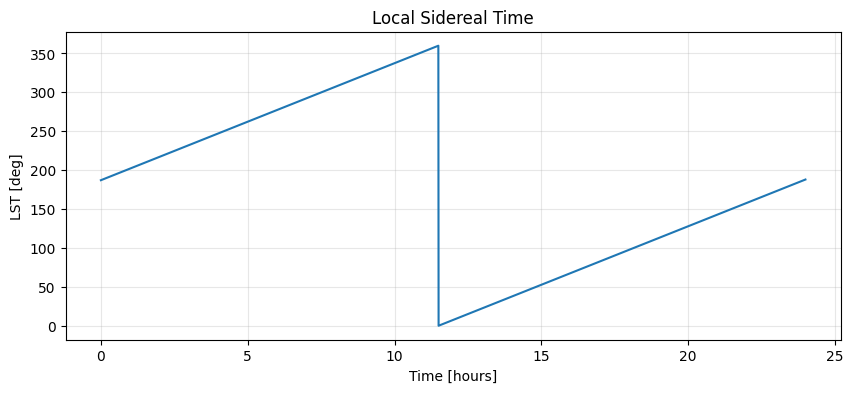

In [26]:
# ============================================================
# GENERATE LSTs
# ============================================================

LST_deg_list = generate_LSTs_deg(
    ant_latitude_deg=ANT_LAT,
    ant_longitude_deg=ANT_LON,
    ant_height_m=ANT_H,
    time_list=time_list,
    start_time_utc=START_TIME,
)

LST_deg_list = np.asarray(LST_deg_list, dtype=float)

print("LST diagnostics")
print("---------------")
print("shape:", LST_deg_list.shape)
print("min  :", np.min(LST_deg_list))
print("max  :", np.max(LST_deg_list))
print("first five:", LST_deg_list[:5])
print("last five :", LST_deg_list[-5:])

plt.figure(figsize=(10, 4))
plt.plot(time_hours, LST_deg_list, lw=1.5)
plt.xlabel("Time [hours]")
plt.ylabel("LST [deg]")
plt.title("Local Sidereal Time")
plt.grid(alpha=0.3)
plt.show()

Gaussian beam diagnostics
-------------------------
NSIDE: 32
NPIX : 12288
min  : 1.0295745688916673e-24
max  : 1.0
mean : 0.04281341942858549
std  : 0.1412625069956807


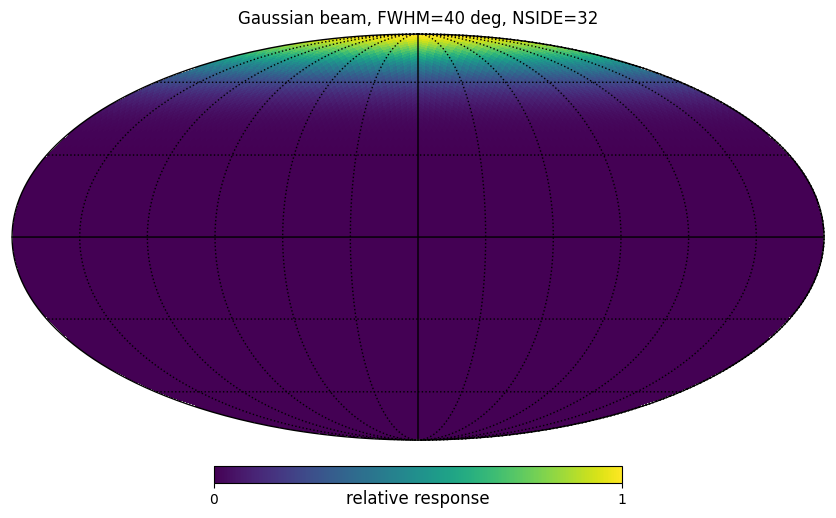

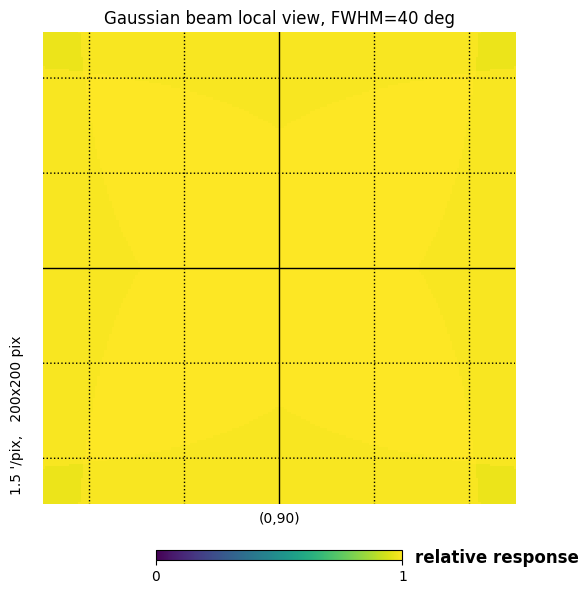

In [27]:
# ============================================================
# MAKE CIRCULAR GAUSSIAN BEAM AT SIM_NSIDE
# ============================================================

def make_circular_gaussian_beam(nside, fwhm_deg):
    """
    Circular Gaussian beam centred on local zenith.

    In HEALPix coordinates:
    theta = 0 is the north pole of the beam map.
    Here that represents the beam boresight / zenith direction.

    Beam is peak-normalised to max = 1.
    """
    npix = hp.nside2npix(nside)

    theta, phi = hp.pix2ang(nside, np.arange(npix))

    fwhm_rad = np.deg2rad(fwhm_deg)
    sigma_rad = fwhm_rad / np.sqrt(8.0 * np.log(2.0))

    beam = np.exp(-0.5 * (theta / sigma_rad)**2)

    beam = np.asarray(beam, dtype=float)
    beam = np.nan_to_num(beam, nan=0.0, posinf=0.0, neginf=0.0)

    if np.max(beam) <= 0:
        raise RuntimeError("Gaussian beam has non-positive maximum.")

    beam /= np.max(beam)

    return beam


gaussian_beam_map = make_circular_gaussian_beam(
    nside=SIM_NSIDE,
    fwhm_deg=GAUSS_FWHM_DEG,
)

beam_map = gaussian_beam_map.copy()

print("Gaussian beam diagnostics")
print("-------------------------")
print("NSIDE:", hp.npix2nside(len(beam_map)))
print("NPIX :", len(beam_map))
print("min  :", np.min(beam_map))
print("max  :", np.max(beam_map))
print("mean :", np.mean(beam_map))
print("std  :", np.std(beam_map))

hp.mollview(
    beam_map,
    title=f"Gaussian beam, FWHM={GAUSS_FWHM_DEG:.0f} deg, NSIDE={SIM_NSIDE}",
    unit="relative response",
    min=0,
    max=1,
    cmap="viridis",
)
hp.graticule()
plt.show()

hp.gnomview(
    beam_map,
    rot=[0, 90],
    title=f"Gaussian beam local view, FWHM={GAUSS_FWHM_DEG:.0f} deg",
    unit="relative response",
    min=0,
    max=1,
    cmap="viridis",
)
hp.graticule()
plt.show()

Sky diagnostics
---------------
NSIDE: 32
NPIX : 12288
min  : -2736.16162109375 K
max  : 73141.6484375 K
mean : 2757.6338613828025 K
std  : 2209.2382783614494 K


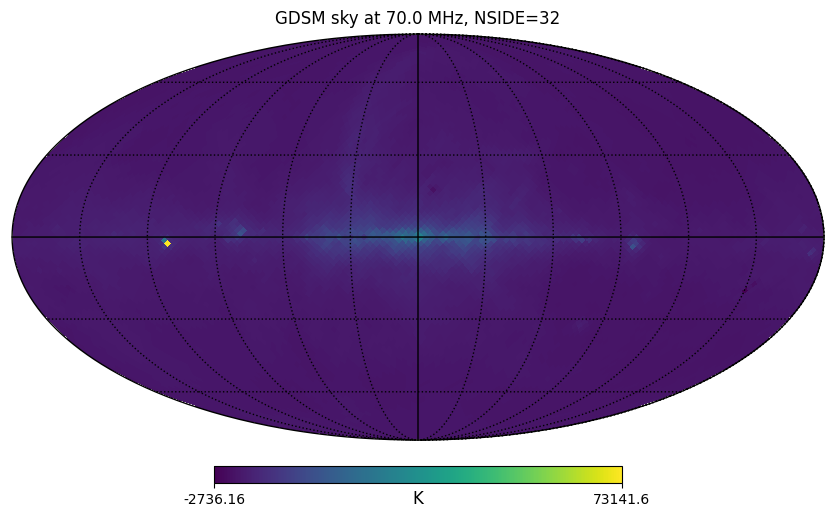

In [28]:
# ============================================================
# GENERATE SKY AT SIM_NSIDE
# ============================================================

sky_map = GDSM_sky_model(
    freq=FREQ_MHZ,
    nside=SIM_NSIDE,
)

sky_map = np.asarray(sky_map, dtype=float)
sky_map = np.nan_to_num(
    sky_map,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
)

print("Sky diagnostics")
print("---------------")
print("NSIDE:", hp.npix2nside(len(sky_map)))
print("NPIX :", len(sky_map))
print("min  :", np.min(sky_map), "K")
print("max  :", np.max(sky_map), "K")
print("mean :", np.mean(sky_map), "K")
print("std  :", np.std(sky_map), "K")

hp.mollview(
    sky_map,
    title=f"GDSM sky at {FREQ_MHZ:.1f} MHz, NSIDE={SIM_NSIDE}",
    unit="K",
    cmap="viridis",
)
hp.graticule()
plt.show()

100%|██████████| 2880/2880 [00:02<00:00, 1099.24it/s]


TOD diagnostics
---------------
shape: (2880,)
min  : 733193.9317544035 K
max  : 1406182.944954143 K
mean : 999204.8181133302 K
std  : 214693.24712884813 K


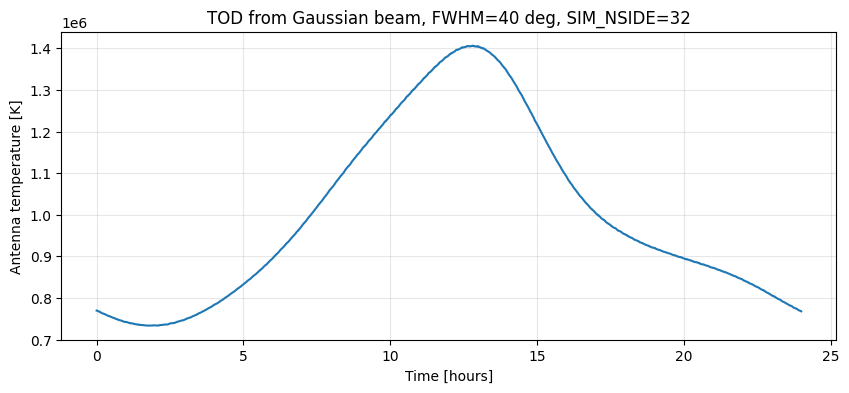

In [29]:
# ============================================================
# GENERATE TOD CONSISTENTLY
# ============================================================

TOD = generate_TOD_sky(
    beam_map=beam_map,
    sky_map=sky_map,
    LST_deg_list=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list=azimuth_deg_list,
    elevation_deg_list=elevation_deg_list,
    selfrot_deg_list=selfrot_deg_list,
    nside_hires=SIM_NSIDE,
    normalize_beam=False,
    truncate_frac_thres=TRUNC_FRAC,
)

TOD = np.asarray(TOD, dtype=float)
TOD = np.nan_to_num(TOD, nan=0.0, posinf=0.0, neginf=0.0)

print("TOD diagnostics")
print("---------------")
print("shape:", TOD.shape)
print("min  :", np.min(TOD), "K")
print("max  :", np.max(TOD), "K")
print("mean :", np.mean(TOD), "K")
print("std  :", np.std(TOD), "K")

plt.figure(figsize=(10, 4))
plt.plot(time_hours, TOD, lw=1.5)
plt.xlabel("Time [hours]")
plt.ylabel("Antenna temperature [K]")
plt.title(
    f"TOD from Gaussian beam, FWHM={GAUSS_FWHM_DEG:.0f} deg, "
    f"SIM_NSIDE={SIM_NSIDE}"
)
plt.grid(alpha=0.3)
plt.show()

100%|██████████| 2880/2880 [00:02<00:00, 1100.67it/s]

Circular Gaussian rotation sanity check
--------------------------------------
max abs difference      : 550.8577869962901 K
mean abs difference     : 52.11547324581548 K
relative norm difference: 9.33127377891845e-05


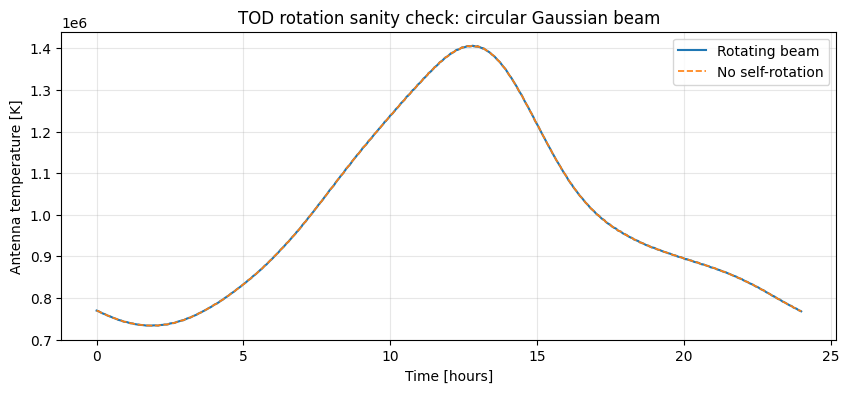

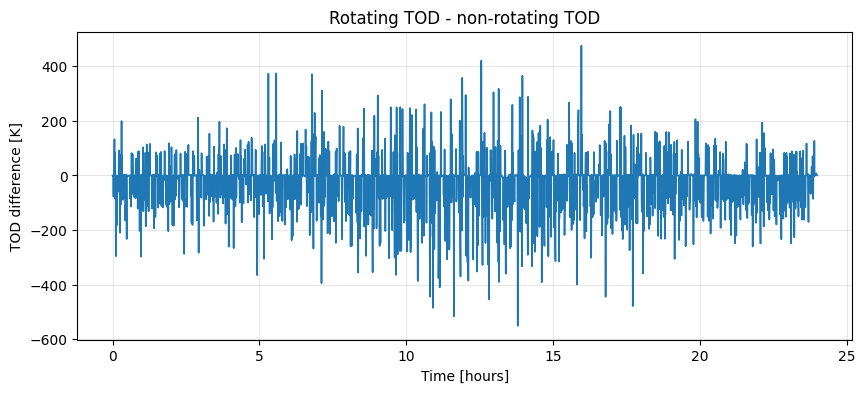

In [30]:
# ============================================================
# ROTATION SANITY CHECK FOR CIRCULAR GAUSSIAN
# ============================================================

selfrot_zero = np.zeros_like(selfrot_deg_list)

TOD_no_rot = generate_TOD_sky(
    beam_map=beam_map,
    sky_map=sky_map,
    LST_deg_list=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list=azimuth_deg_list,
    elevation_deg_list=elevation_deg_list,
    selfrot_deg_list=selfrot_zero,
    nside_hires=SIM_NSIDE,
    normalize_beam=False,
    truncate_frac_thres=TRUNC_FRAC,
)

TOD_no_rot = np.asarray(TOD_no_rot, dtype=float)
TOD_no_rot = np.nan_to_num(TOD_no_rot, nan=0.0, posinf=0.0, neginf=0.0)

diff_rot = TOD - TOD_no_rot

print("Circular Gaussian rotation sanity check")
print("--------------------------------------")
print("max abs difference      :", np.max(np.abs(diff_rot)), "K")
print("mean abs difference     :", np.mean(np.abs(diff_rot)), "K")
print("relative norm difference:", np.linalg.norm(diff_rot) / np.linalg.norm(TOD))

plt.figure(figsize=(10, 4))
plt.plot(time_hours, TOD, label="Rotating beam", lw=1.5)
plt.plot(time_hours, TOD_no_rot, "--", label="No self-rotation", lw=1.2)
plt.xlabel("Time [hours]")
plt.ylabel("Antenna temperature [K]")
plt.title("TOD rotation sanity check: circular Gaussian beam")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_hours, diff_rot, lw=1.2)
plt.xlabel("Time [hours]")
plt.ylabel("TOD difference [K]")
plt.title("Rotating TOD - non-rotating TOD")
plt.grid(alpha=0.3)
plt.show()

In [31]:
# ============================================================
# CREATE CONSISTENT MAPMAKER
# ============================================================

mapper = HPW_mapmaking(
    beam_map=beam_map,
    LST_deg_list_group=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list_group=azimuth_deg_list,
    elevation_deg_list_group=elevation_deg_list,
    selfrot_deg_list_group=selfrot_deg_list,
    threshold=THRESHOLD,
    beam_truncate_frac_thres=TRUNC_FRAC,
    nside_hires=SIM_NSIDE,
    nside_target=MAP_NSIDE,
)

print("Mapmaker created successfully")
print("-----------------------------")
print("num_tods    :", mapper.num_tods)
print("num_pixels  :", mapper.num_pixels)
print("nsky_params :", mapper.nsky_params)
print("nside_hires :", mapper.nside_hires)
print("nside_target:", mapper.nside_target)

# Get selected map pixels
pix = np.asarray(mapper.pixel_indices, dtype=int)

print("\nSelected pixel diagnostics")
print("--------------------------")
print("number of selected pixels:", len(pix))
print("min pixel:", np.min(pix))
print("max pixel:", np.max(pix))
print("MAP_NSIDE npix:", hp.nside2npix(MAP_NSIDE))


Step 1: Generating the stacked abs(beam) map ... 



100%|██████████| 2880/2880 [00:02<00:00, 1257.71it/s]



Step 2: Selecting pixels above threshold sensitivity ... 

Number of data points: 2880
Number of selected pixels: 72


100%|██████████| 2880/2880 [00:02<00:00, 1280.86it/s]

Mapmaker created successfully
-----------------------------
num_tods    : 1
num_pixels  : 72
nsky_params : 72
nside_hires : 32
nside_target: 4

Selected pixel diagnostics
--------------------------
number of selected pixels: 72
min pixel: 0
max pixel: 71
MAP_NSIDE npix: 192


In [32]:
truth_patch = sky_map[pix]

# ============================================================
# DEFINE TRUTH PATCH
# ============================================================

# if SIM_NSIDE != MAP_NSIDE:
#     raise RuntimeError(
#         "This clean consistency block assumes SIM_NSIDE == MAP_NSIDE. "
#         "Do not degrade the truth map here."
#     )

truth_map = sky_map.copy()
truth_patch = truth_map[pix]

truth_patch = np.asarray(truth_patch, dtype=float)

print("Truth patch diagnostics")
print("-----------------------")
print("truth map NSIDE :", hp.npix2nside(len(truth_map)))
print("truth map NPIX  :", len(truth_map))
print("selected pixels :", len(pix))
print("truth patch shape:", truth_patch.shape)
print("truth min/max   :", np.min(truth_patch), np.max(truth_patch))
print("truth mean/std  :", np.mean(truth_patch), np.std(truth_patch))

Truth patch diagnostics
-----------------------
truth map NSIDE : 32
truth map NPIX  : 12288
selected pixels : 72
truth patch shape: (72,)
truth min/max   : 1324.282470703125 1859.661376953125
truth mean/std  : 1636.3230980767144 120.37162123049701


Operator diagnostics
--------------------
A shape: (2880, 72)
TOD shape: (2880,)
truth_patch shape: (72,)

Forward consistency check
-------------------------
relative error = 9.875449e-01
forward TOD min/max: 11806.329328338801 13864.137360572382
input TOD min/max  : 733193.9317544035 1406182.944954143
residual min/max   : -1392467.4883362867 -720484.557369435
residual mean/std  : -986282.2006692982 214229.1463306425


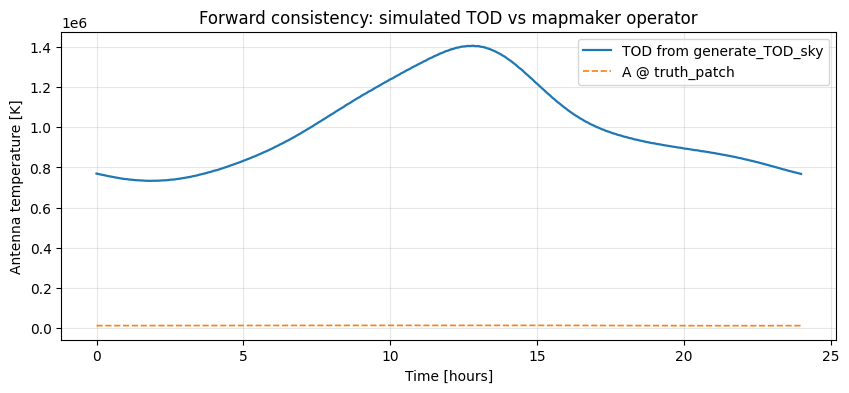

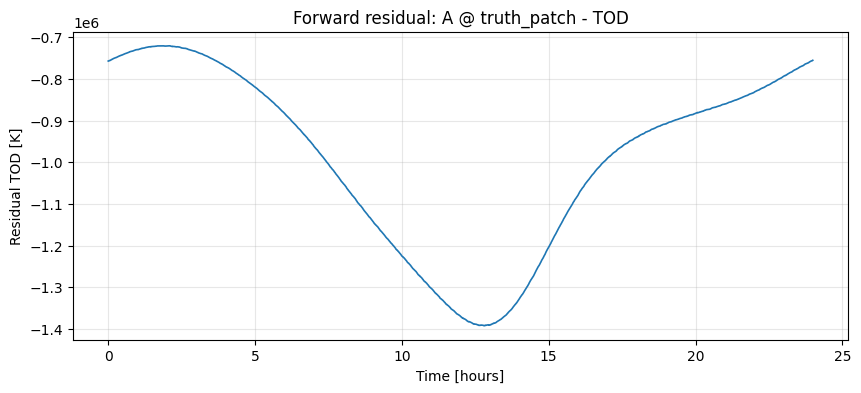

In [33]:
# ============================================================
# FORWARD CONSISTENCY CHECK
# ============================================================

A = mapper.Tsys_operators

print("Operator diagnostics")
print("--------------------")
print("A shape:", A.shape)
print("TOD shape:", TOD.shape)
print("truth_patch shape:", truth_patch.shape)

forward_TOD = A @ truth_patch

forward_residual = forward_TOD - TOD

forward_rel_err = np.linalg.norm(forward_residual) / np.linalg.norm(TOD)

print("\nForward consistency check")
print("-------------------------")
print(f"relative error = {forward_rel_err:.6e}")
print("forward TOD min/max:", np.min(forward_TOD), np.max(forward_TOD))
print("input TOD min/max  :", np.min(TOD), np.max(TOD))
print("residual min/max   :", np.min(forward_residual), np.max(forward_residual))
print("residual mean/std  :", np.mean(forward_residual), np.std(forward_residual))

plt.figure(figsize=(10, 4))
plt.plot(time_hours, TOD, label="TOD from generate_TOD_sky", lw=1.6)
plt.plot(time_hours, forward_TOD, "--", label="A @ truth_patch", lw=1.2)
plt.xlabel("Time [hours]")
plt.ylabel("Antenna temperature [K]")
plt.title("Forward consistency: simulated TOD vs mapmaker operator")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_hours, forward_residual, lw=1.2)
plt.xlabel("Time [hours]")
plt.ylabel("Residual TOD [K]")
plt.title("Forward residual: A @ truth_patch - TOD")
plt.grid(alpha=0.3)
plt.show()

In [34]:
# ============================================================
# RUN MAPMAKER
# ============================================================

sky_est_patch, sky_unc_patch = mapper(
    TOD_group=TOD,
    dtime=DT,
    cutoff_freq_group=CUTOFF_FREQ,
    gain_group=1.0,
    Tsky_prior_mean=None,
    Tsky_prior_inv_cov_diag=None,
    noise_variance=None,
    regularization=REGULARIZATION,
    filter_order=FILTER_ORDER,
    preserve_dc=False,
    use_high_pass=USE_HIGH_PASS,
)

sky_est_patch = np.asarray(sky_est_patch, dtype=float)
sky_unc_patch = np.asarray(sky_unc_patch, dtype=float)

print("Mapmaker output diagnostics")
print("---------------------------")
print("sky_est_patch shape:", sky_est_patch.shape)
print("sky_unc_patch shape:", sky_unc_patch.shape)
print("truth_patch shape  :", truth_patch.shape)

print("\nRecovered patch:")
print("min :", np.min(sky_est_patch))
print("max :", np.max(sky_est_patch))
print("mean:", np.mean(sky_est_patch))
print("std :", np.std(sky_est_patch))

print("\nUncertainty patch:")
print("min :", np.min(sky_unc_patch))
print("max :", np.max(sky_unc_patch))
print("mean:", np.mean(sky_unc_patch))
print("std :", np.std(sky_unc_patch))

Mapmaker output diagnostics
---------------------------
sky_est_patch shape: (72,)
sky_unc_patch shape: (72,)
truth_patch shape  : (72,)

Recovered patch:
min : 6006.896775752696
max : 272419.48493014136
mean: 91590.5359192235
std : 63926.36633250155

Uncertainty patch:
min : 824.22724780955
max : 984.4301861836454
mean: 916.3221385235634
std : 59.1747056776205


Reconstruction metrics
----------------------
SIM_NSIDE       : 32
MAP_NSIDE       : 4
Selected pixels : 72
TOD samples     : 2880
Forward rel err : 9.875449e-01
RMSE [K]        : 110337.240601
Relative RMSE   : 6.742998e+01
Bias [K]        : 89954.212821
Correlation     : 0.263066


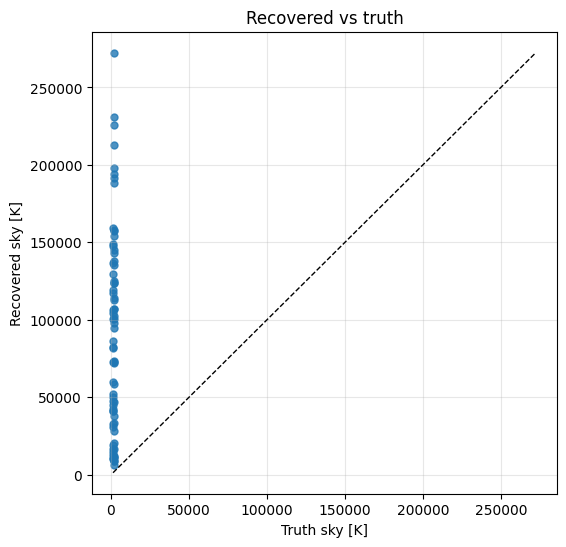

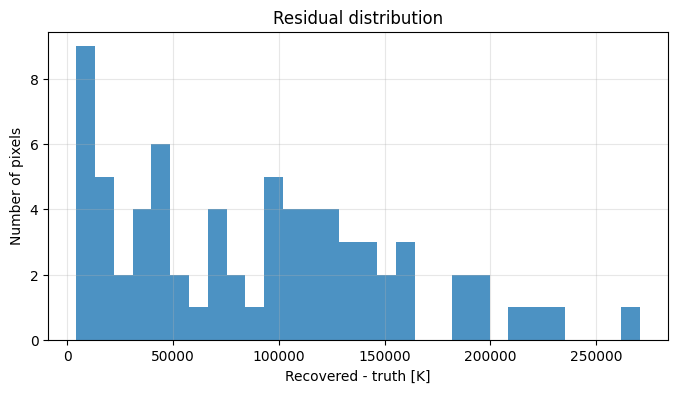

In [35]:
# ============================================================
# RECONSTRUCTION METRICS
# ============================================================

residual_patch = sky_est_patch - truth_patch

rmse = np.sqrt(np.mean(residual_patch**2))
bias = np.mean(residual_patch)

if np.std(sky_est_patch) > 0 and np.std(truth_patch) > 0:
    corr = np.corrcoef(sky_est_patch, truth_patch)[0, 1]
else:
    corr = np.nan

rel_rmse = rmse / np.mean(np.abs(truth_patch))

print("Reconstruction metrics")
print("----------------------")
print(f"SIM_NSIDE       : {SIM_NSIDE}")
print(f"MAP_NSIDE       : {MAP_NSIDE}")
print(f"Selected pixels : {len(pix)}")
print(f"TOD samples     : {len(TOD)}")
print(f"Forward rel err : {forward_rel_err:.6e}")
print(f"RMSE [K]        : {rmse:.6f}")
print(f"Relative RMSE   : {rel_rmse:.6e}")
print(f"Bias [K]        : {bias:.6f}")
print(f"Correlation     : {corr:.6f}")

plt.figure(figsize=(6, 6))
plt.scatter(truth_patch, sky_est_patch, s=25, alpha=0.8)
lo = min(np.min(truth_patch), np.min(sky_est_patch))
hi = max(np.max(truth_patch), np.max(sky_est_patch))
plt.plot([lo, hi], [lo, hi], "k--", lw=1)
plt.xlabel("Truth sky [K]")
plt.ylabel("Recovered sky [K]")
plt.title("Recovered vs truth")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(residual_patch, bins=30, alpha=0.8)
plt.xlabel("Recovered - truth [K]")
plt.ylabel("Number of pixels")
plt.title("Residual distribution")
plt.grid(alpha=0.3)
plt.show()

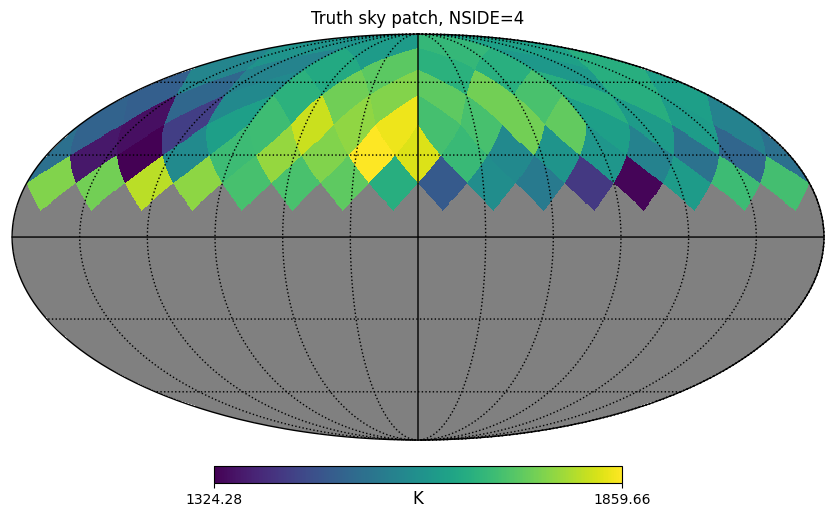

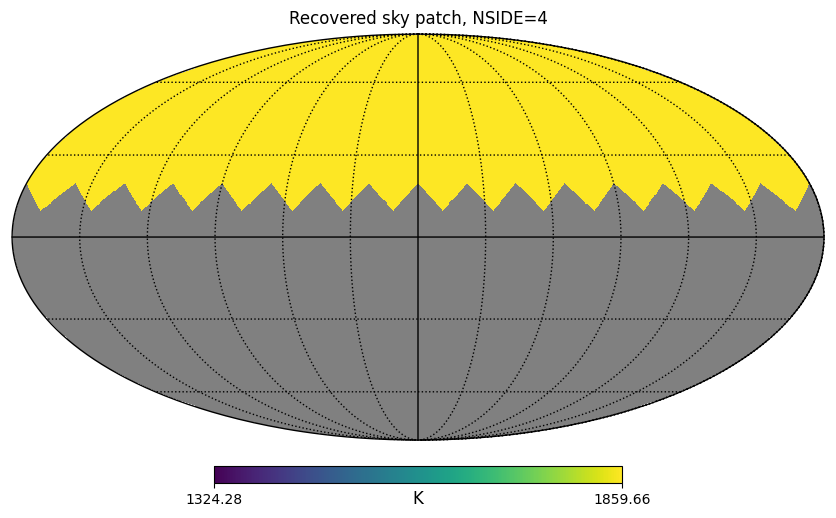

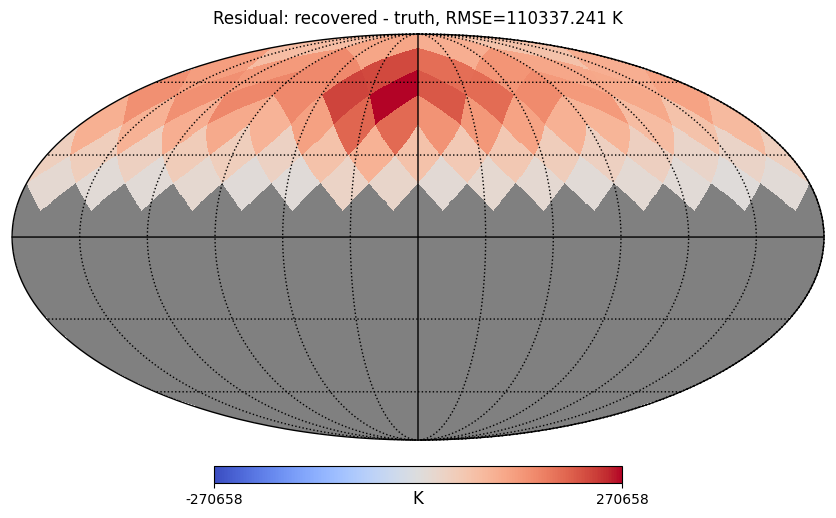

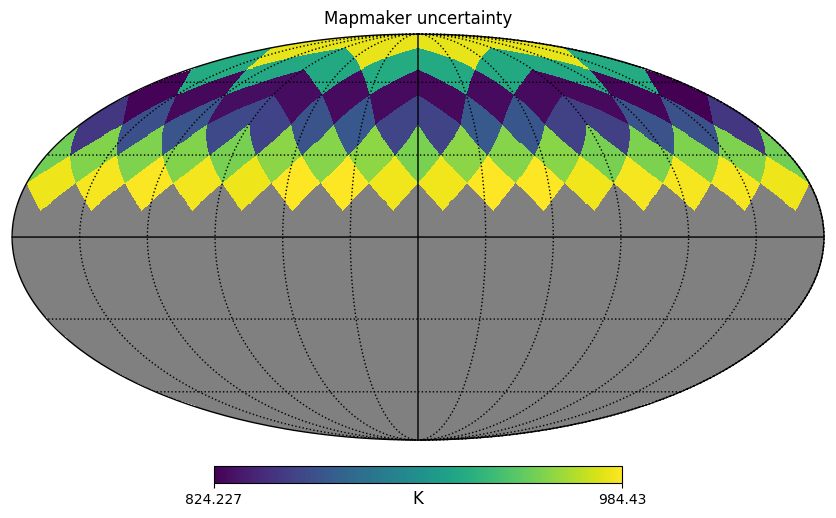

In [36]:
# ============================================================
# PLOT MAPS
# ============================================================

def patch_to_full_map(pix, values, nside, unseen=hp.UNSEEN):
    full_map = np.full(hp.nside2npix(nside), unseen, dtype=float)
    full_map[pix] = values
    return full_map


truth_full = patch_to_full_map(
    pix=pix,
    values=truth_patch,
    nside=MAP_NSIDE,
)

recovered_full = patch_to_full_map(
    pix=pix,
    values=sky_est_patch,
    nside=MAP_NSIDE,
)

residual_full = patch_to_full_map(
    pix=pix,
    values=residual_patch,
    nside=MAP_NSIDE,
)

unc_full = patch_to_full_map(
    pix=pix,
    values=sky_unc_patch,
    nside=MAP_NSIDE,
)

vmin = np.min(truth_patch)
vmax = np.max(truth_patch)

hp.mollview(
    truth_full,
    title=f"Truth sky patch, NSIDE={MAP_NSIDE}",
    unit="K",
    min=vmin,
    max=vmax,
    cmap="viridis",
)
hp.graticule()
plt.show()

hp.mollview(
    recovered_full,
    title=f"Recovered sky patch, NSIDE={MAP_NSIDE}",
    unit="K",
    min=vmin,
    max=vmax,
    cmap="viridis",
)
hp.graticule()
plt.show()

res_lim = np.max(np.abs(residual_patch))

hp.mollview(
    residual_full,
    title=f"Residual: recovered - truth, RMSE={rmse:.3f} K",
    unit="K",
    min=-res_lim,
    max=res_lim,
    cmap="coolwarm",
)
hp.graticule()
plt.show()

hp.mollview(
    unc_full,
    title="Mapmaker uncertainty",
    unit="K",
    cmap="viridis",
)
hp.graticule()
plt.show()

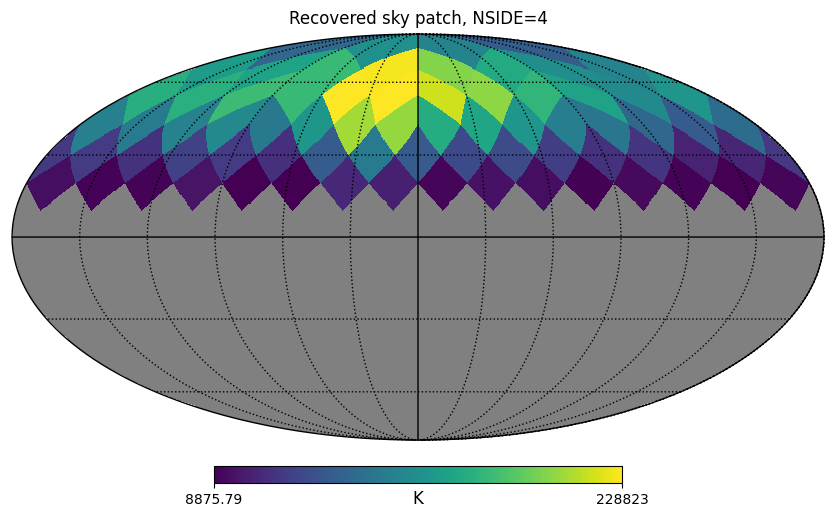

In [37]:
hp.mollview(
    recovered_full,
    title=f"Recovered sky patch, NSIDE={MAP_NSIDE}",
    unit="K",
    min=np.nanpercentile(sky_est_patch, 2),
    max=np.nanpercentile(sky_est_patch, 98),
    cmap="viridis",
)
hp.graticule()
plt.show()

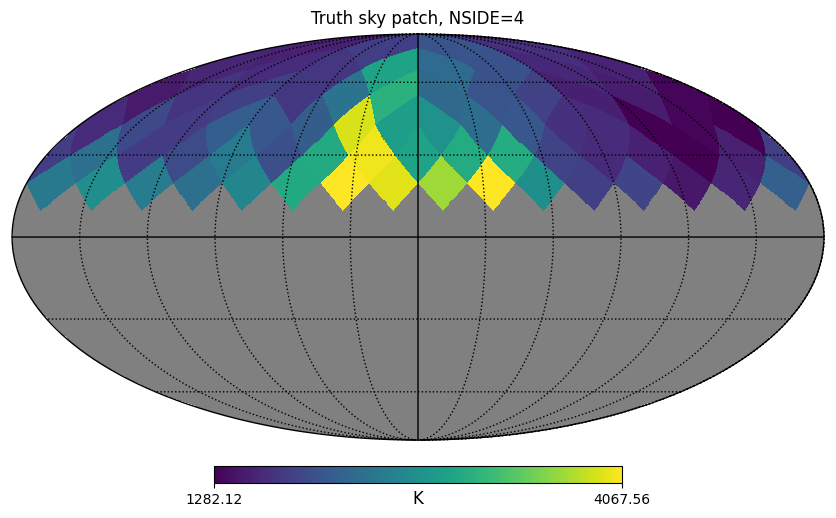

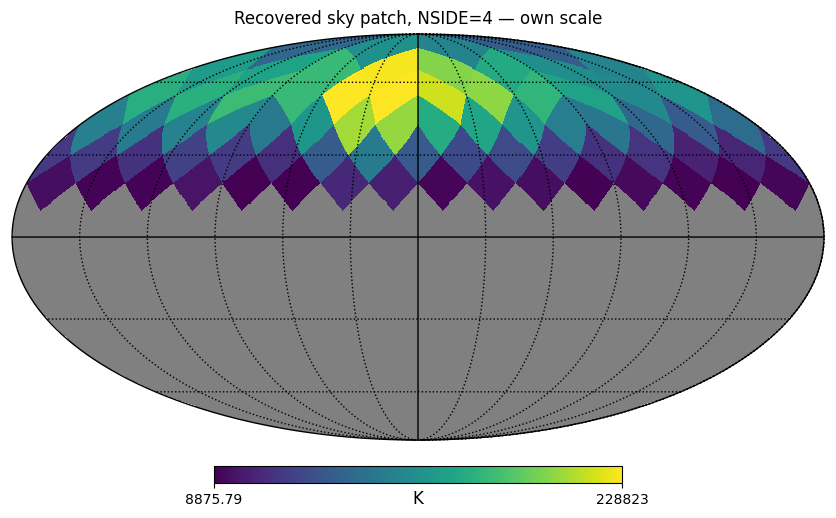

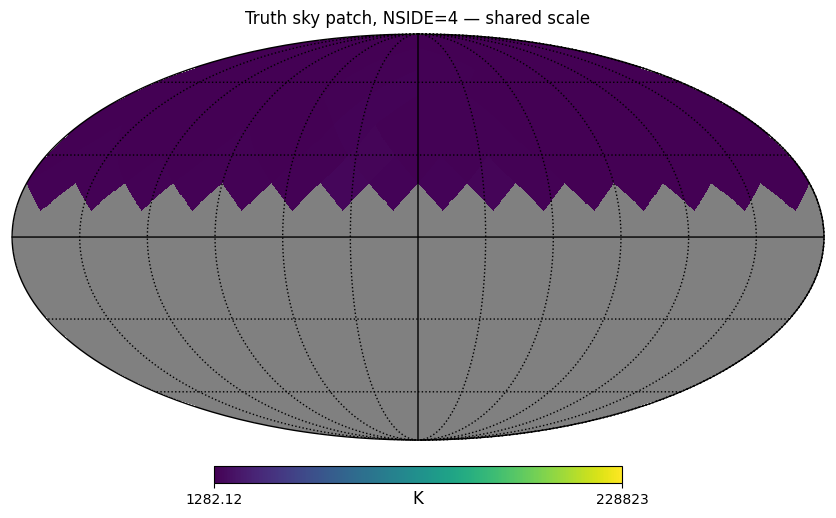

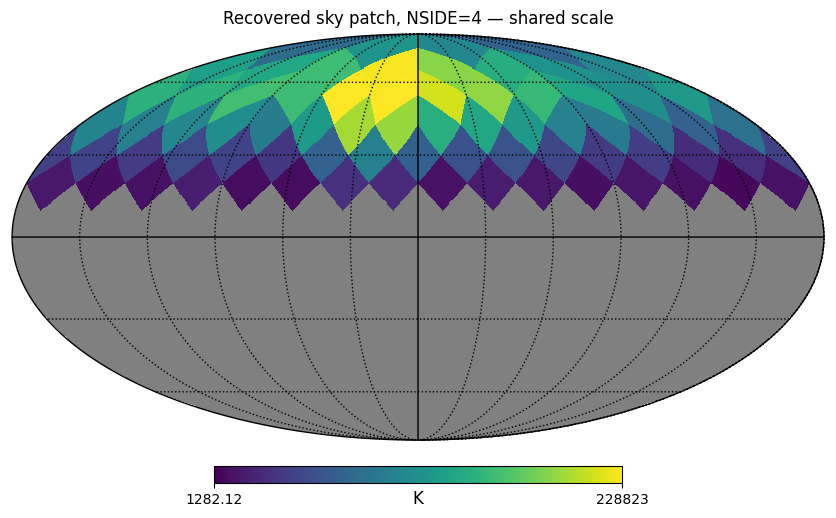

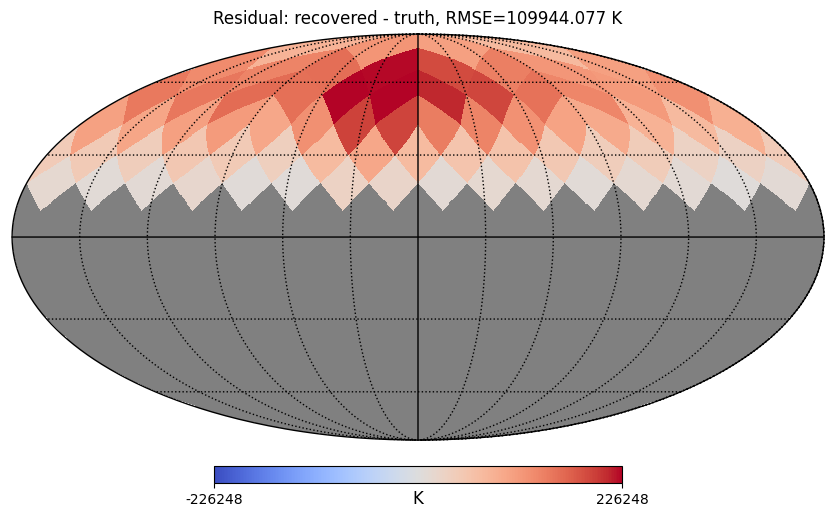

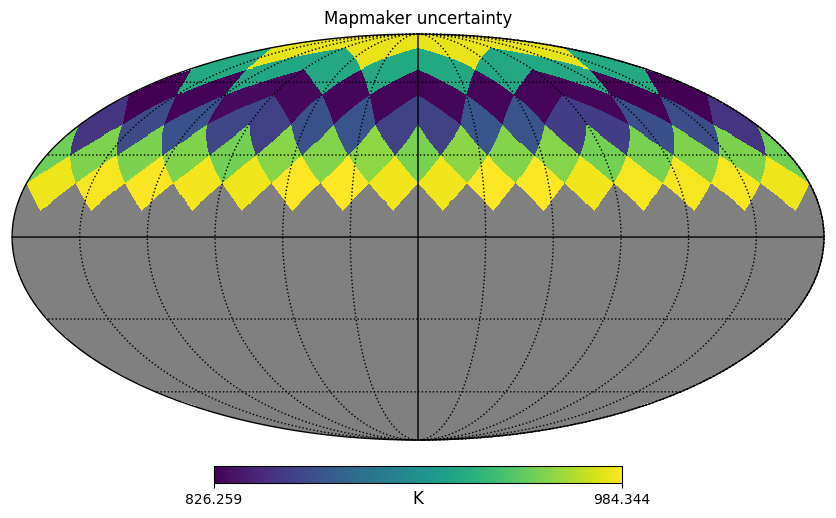

In [39]:
# ============================================================
# PLOT MAPS -- FIXED / SAFER
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

def patch_to_full_map(pix, values, nside, unseen=hp.UNSEEN):
    full_map = np.full(hp.nside2npix(nside), unseen, dtype=float)
    full_map[pix] = values
    return full_map


# Use only good pixels from the metrics cell
truth_full = patch_to_full_map(
    pix=pix_good,
    values=truth_patch_good,
    nside=MAP_NSIDE,
)

recovered_full = patch_to_full_map(
    pix=pix_good,
    values=sky_est_patch_good,
    nside=MAP_NSIDE,
)

residual_full = patch_to_full_map(
    pix=pix_good,
    values=residual_patch_good,
    nside=MAP_NSIDE,
)

unc_full = patch_to_full_map(
    pix=pix_good,
    values=sky_unc_patch_good,
    nside=MAP_NSIDE,
)

# ------------------------------------------------------------
# Colour limits
# ------------------------------------------------------------

# Truth scale
truth_vmin = np.nanpercentile(truth_patch_good, 2)
truth_vmax = np.nanpercentile(truth_patch_good, 98)

# Recovered scale: DO NOT force this to truth scale unless recovery is sane
rec_vmin = np.nanpercentile(sky_est_patch_good, 2)
rec_vmax = np.nanpercentile(sky_est_patch_good, 98)

# Shared scale for direct visual comparison
shared_vmin = min(truth_vmin, rec_vmin)
shared_vmax = max(truth_vmax, rec_vmax)

# Residual scale
res_lim = np.nanpercentile(np.abs(residual_patch_good), 98)

# Uncertainty scale
unc_vmin = np.nanpercentile(sky_unc_patch_good, 2)
unc_vmax = np.nanpercentile(sky_unc_patch_good, 98)

# ------------------------------------------------------------
# 1. Truth map
# ------------------------------------------------------------
hp.mollview(
    truth_full,
    title=f"Truth sky patch, NSIDE={MAP_NSIDE}",
    unit="K",
    min=truth_vmin,
    max=truth_vmax,
    cmap="viridis",
)
hp.graticule()
plt.show()

# ------------------------------------------------------------
# 2. Recovered map on its OWN scale
# ------------------------------------------------------------
hp.mollview(
    recovered_full,
    title=f"Recovered sky patch, NSIDE={MAP_NSIDE} — own scale",
    unit="K",
    min=rec_vmin,
    max=rec_vmax,
    cmap="viridis",
)
hp.graticule()
plt.show()

# ------------------------------------------------------------
# 3. Truth and recovered on SHARED scale
# ------------------------------------------------------------
hp.mollview(
    truth_full,
    title=f"Truth sky patch, NSIDE={MAP_NSIDE} — shared scale",
    unit="K",
    min=shared_vmin,
    max=shared_vmax,
    cmap="viridis",
)
hp.graticule()
plt.show()

hp.mollview(
    recovered_full,
    title=f"Recovered sky patch, NSIDE={MAP_NSIDE} — shared scale",
    unit="K",
    min=shared_vmin,
    max=shared_vmax,
    cmap="viridis",
)
hp.graticule()
plt.show()

# ------------------------------------------------------------
# 4. Residual map
# ------------------------------------------------------------
hp.mollview(
    residual_full,
    title=f"Residual: recovered - truth, RMSE={rmse:.3f} K",
    unit="K",
    min=-res_lim,
    max=res_lim,
    cmap="coolwarm",
)
hp.graticule()
plt.show()

# ------------------------------------------------------------
# 5. Uncertainty map
# ------------------------------------------------------------
hp.mollview(
    unc_full,
    title="Mapmaker uncertainty",
    unit="K",
    min=unc_vmin,
    max=unc_vmax,
    cmap="viridis",
)
hp.graticule()
plt.show()